### 1. Problem & Project Definition

i. Business problem  
A real estate company wants to understand   property value factors and support better pricing decisions.

ii. Decision lens 
→ Price Prediction 

iii.  Stakeholder and Decision need
| No. | Stakeholder | Decision Need |
|---|---|---|
||**Primary Stakeholders**|| 
| 1 | **Real Estate Agents & Brokers** | To estimate a property's market value from its characteristics and use the estimate to set a realistic and competitive listing price. |
|| **Secondary Stakeholders**||  
| 1 | **Certified Appraisers** | To use the estimated property value as supporting information when deciding an appropriate asking price for the property. |
| 2 | **The Seller (Property Owner)** | To use data-driven property-value estimates as supplementary information when assessing the value of a property. |
| 3 | **Property Investors & Developers** | To use estimated property values to support property purchasing and investment decisions. |
| 4 | **Buyers** | To check if the asking price is fair so they do not overpay for a home. |
     
iv. Unit of analysis 
→ property

v. ML task 
→ Regression
Because here we predict the sales price not just choosing a class

vi. Target 
→ Sale Price

vii. Expected output 
→ estimated Sale Price

viii. Why ML is suitable
ML is suitable for this problem because it can learn the relationships between different property features and their sale prices from historical data. The trained model can then use these patterns to predict the sale price of a new property and support better pricing decisions.


### 2. Dataset Understanding

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

##### 2.1 Load Training Dataset

In [19]:
file_id = "1To_n4yys1lnWwbQ7bvRDYW8B_f2gfEud"

gdown.download(
    id=file_id,
    output="dataset.csv",
    quiet=False
)

df = pd.read_csv("dataset.csv")

df.head()

Downloading...
From: https://drive.google.com/uc?id=1To_n4yys1lnWwbQ7bvRDYW8B_f2gfEud
To: c:\1. SLIIT\Y3S1\ML\Assignment\ames-housing-price-prediction\dataset.csv
100%|██████████| 461k/461k [00:00<00:00, 1.12MB/s]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [20]:
# df = pd.read_csv("https://drive.google.com/file/d/1Ys_QhDgt_15kFixVB6SwSv24afhKiOQf/view?usp=drive_link")

##### 2.2 Dataset Dimensions

In [21]:
df.shape

(1460, 81)

##### 2.3 Initial Dataset Inspection

In [22]:
print('First 5 rows of the DataFrame:\n', df.head())

First 5 rows of the DataFrame:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  S

In [23]:
print('Additional information:\n ')
df.info()

Additional information:
 
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64 

##### 2.4 Features and Target

In [24]:
df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

Target

In [25]:
df['SalePrice'].dtype

dtype('int64')

In [26]:
df["SalePrice"].head(3)

0    208500
1    181500
2    223500
Name: SalePrice, dtype: int64

In [27]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

##### 2.5 Data Types

In [28]:
pd.set_option('display.max_rows', None)
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
Alley                str
LotShape             str
LandContour          str
Utilities            str
LotConfig            str
LandSlope            str
Neighborhood         str
Condition1           str
Condition2           str
BldgType             str
HouseStyle           str
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle            str
RoofMatl             str
Exterior1st          str
Exterior2nd          str
MasVnrType           str
MasVnrArea       float64
ExterQual            str
ExterCond            str
Foundation           str
BsmtQual             str
BsmtCond             str
BsmtExposure         str
BsmtFinType1         str
BsmtFinSF1         int64
BsmtFinType2         str
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating              str


Binary Variables: Utilities, Street and CentralAir are binary categorical variables because each contains two possible categories.

##### 2.6 Numerical Variables

In [29]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns.tolist()

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [30]:
len(numerical_columns)

38

In [31]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


##### 2.7 Categorical Variables

In [32]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns.tolist()

C:\Users\dampa\AppData\Local\Temp\ipykernel_3700\2750784672.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [34]:
len(categorical_columns)

43

##### Looking at the types of each category

In [35]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


MSZoning
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Street
<StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Alley
<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

LotShape
<StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str

LandContour
<StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str

Utilities
<StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str

LotConfig
<StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str

LandSlope
<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

Neighborhood
<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Condition1
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', '

##### 2.8 Ordinal Variables

In [36]:
ordinal_columns = [
    'LotShape',
    'LandSlope',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PavedDrive',
    'PoolQC',
    'Fence'

]

_Ordinal variables are categories that have a meaningful order or ranking.  In this dataset, these are the several variables that represent such level. The identified ordinal variables and their number of unique categories are shown below._

In [37]:
df[ordinal_columns].nunique().sort_values()

LandSlope       3
PavedDrive      3
GarageFinish    3
PoolQC          3
BsmtExposure    4
BsmtCond        4
ExterQual       4
LotShape        4
KitchenQual     4
BsmtQual        4
Fence           4
ExterCond       5
GarageCond      5
FireplaceQu     5
GarageQual      5
HeatingQC       5
BsmtFinType1    6
Functional      7
dtype: int64

##### 2.9 Understanding Variables

1. House / Property Characteristics
- LotFrontage — Linear feet of street connected to property
- LotArea — Lot size
- LotShape — Shape of property
- LandContour — Flatness/contour
- LandSlope — Slope
- LotConfig — Lot configuration
- BldgType — Type of dwelling
- HouseStyle — Style of dwelling
- OverallQual — Overall material/finish quality
- OverallCond — Overall condition
- YearBuilt — Construction year
- YearRemodAdd — Remodeling year
- 1stFlrSF — First-floor area
- 2ndFlrSF — Second-floor area
- GrLivArea — Above-ground living area
- BedroomAbvGr / Bedroom — Bedrooms
- KitchenAbvGr / Kitchen — Kitchens
- TotRmsAbvGrd — Total rooms
- FullBath — Full bathrooms
- HalfBath — Half bathrooms
- BsmtFullBath — Basement full bathrooms
- BsmtHalfBath — Basement half bathrooms

2. Basement Features
- BsmtQual --> height of the basement
- BsmtCond --> general condition of the basement
- BsmtExposure --> walkout or garden level walls
- BsmtFinType1 --> Rating of basement finished area
- BsmtFinType2 --> Rating of basement finished are
- BsmtFinSF1 --> Type 1 finished square feet
- BsmtFinSF2 --> Type 2 finished square feet
- BsmtUnfSF --> Unfinished square feet of basement area
- TotalBsmtSF --> Total square feet of basement area

3. Garage Features
- GarageType --> Garage location
- GarageYrBlt --> Year garage was built
- GarageFinish --> Interior finish of the garage
- GarageCars --> Size of garage in car capacity
- GarageArea --> Size of garage in square feet
- GarageQual --> Garage quality
- GarageCond --> Garage condition

4. House Systems / Utilities
- Heating --> Type of heating
- HeatingQC --> Heating quality and condition
- CentralAir --> Central air conditioning
- Electrical --> Electrical system
- Utilities --> Type of utilities available

5. Exterior / Construction
- RoofStyle --> Type of roof
- RoofMatl --> Roof material
- Exterior1st --> Exterior covering on house
- Exterior2nd --> Exterior covering on house (if more than one material)
- MasVnrType --> Masonry veneer type
- MasVnrArea --> Masonry veneer area in square feet
- ExterQual --> quality of the material on the exterior
- ExterCond --> present condition of the material on the exterior
- Foundation --> Type of foundation

6. Outdoor Features
- WoodDeckSF --> Wood deck area in square feet
- OpenPorchSF --> Open porch area in square feet
- EnclosedPorch --> Enclosed porch area in square feet
- 3SsnPorch --> Three season porch area in square feet
- ScreenPorch --> Screen porch area in square feet
- PoolArea --> Pool area in square feet
- PoolQC --> Pool quality
- Fence --> Fence quality
- MiscFeature --> Miscellaneous feature not covered in other categories
- MiscVal --> Value of miscellaneous feature

7. Location / Access
- MSZoning --> general zoning classification of the sale
- Street --> Type of road access to property
- Alley --> Type of alley access to property
- Neighborhood --> Physical locations within Ames city limits
- Condition1 --> Proximity to various conditions
- Condition2 --> Proximity to various conditions (if more than 1 is present)


8. Sale / Transaction Features
- MoSold
- YrSold
- SaleType
- SaleCondition

The dataset contains 81 columns and 1,460 observations. The target variable is SalePrice. Among the 81 columns, 38 are numerical variables and 43 are categorical variables. Since SalePrice is the numerical target variable, there are 37 numerical predictor features and 43 categorical predictor features, giving a total of 80 input features.

By examining the categorical variables, we also identified categorical features with a meaningful order, which can be considered ordinal variables. In addition, two categorical variables, Street and CentralAir, are binary variables because each contains two possible categories. These represent the main data types identified in the dataset.

### 3. Data Quality

##### 3.1 Missing Values

_For Numerical Data_

In [38]:
numerical_missing = df[numerical_columns].isnull().sum()
numerical_missing = numerical_missing[numerical_missing > 0]

numerical_missing

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

_For Categorical Data_

In [39]:
categorical_missing = df[categorical_columns].isnull().sum()
categorical_missing = categorical_missing[categorical_missing > 0]

categorical_missing

Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

##### 3.2 Meaning of Missing Values

_Numerical Data_
- LotFrontage --> No meaning  
- MasVnrArea  --> No meaning     
- GarageYrBlt --> No meaning

_Categorical Data_
- Alley -->  No alley access         
- MasVnrType --> None Masonry veneer     
- BsmtQual --> No basement         
- BsmtCond --> No basement         
- BsmtExposure --> No basement     
- BsmtFinType1 --> No basement     
- BsmtFinType2 --> No basement     
- Electrical --> No meaning       
- FireplaceQu --> No fireplace   
- GarageType --> No garage     
- GarageFinish --> No garage    
- GarageQual --> No garage       
- GarageCond --> No garage       
- PoolQC --> No garage         
- Fence --> No garage         
- MiscFeature --> None (no miscellaneous feature)   

##### 3.3 Duplicates

In [40]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

No Duplicates exists

##### 3.4 Invalid/Inconsistent Values

In [41]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


MSZoning
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Street
<StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Alley
<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

LotShape
<StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str

LandContour
<StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str

Utilities
<StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str

LotConfig
<StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str

LandSlope
<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

Neighborhood
<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Condition1
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', '

C:\Users\dampa\AppData\Local\Temp\ipykernel_3700\1091807614.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [42]:
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- MSZoning ---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

--- Street ---
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

--- Alley ---
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

--- LotShape ---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

--- LandContour ---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

--- Utilities ---
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

--- LotConfig ---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

--- LandSlope ---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

--- Neighborhood ---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSid

In [43]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [44]:
#check for negative values in numerical columns
(df[numerical_columns] < 0).sum().sort_values(ascending=False)

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

##### 3.5 Outliers

_Numerical boxplots_

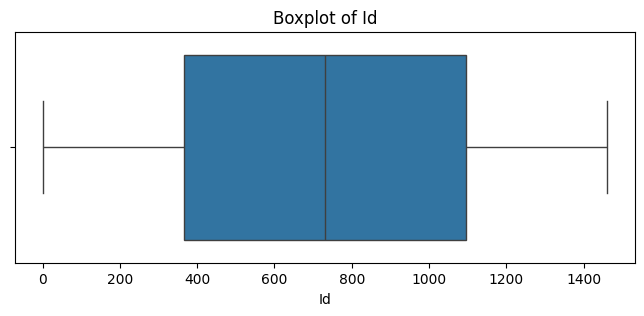

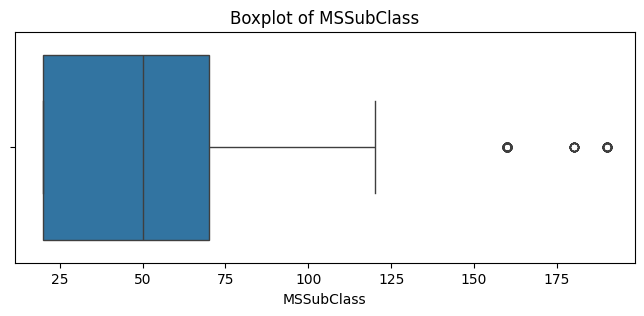

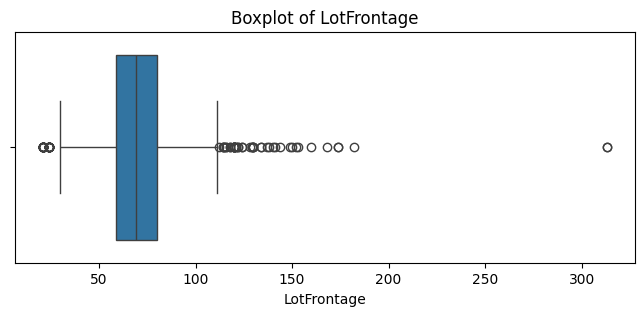

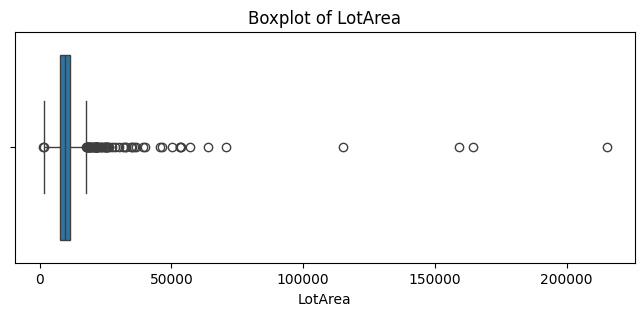

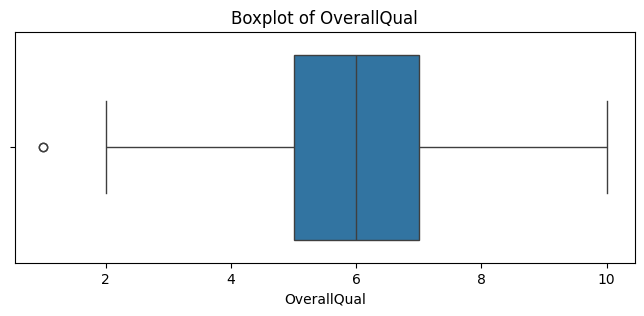

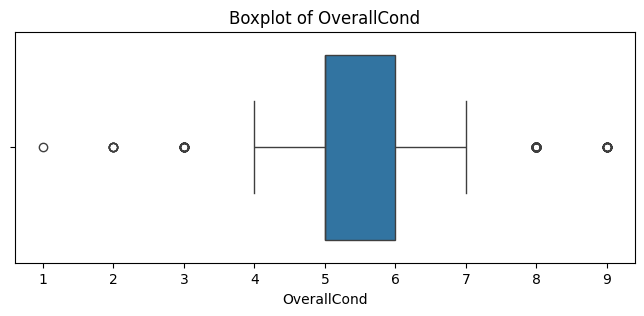

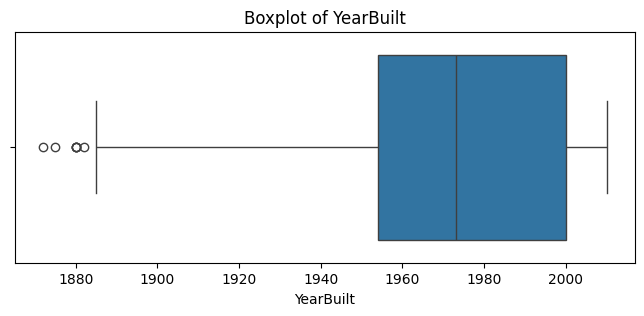

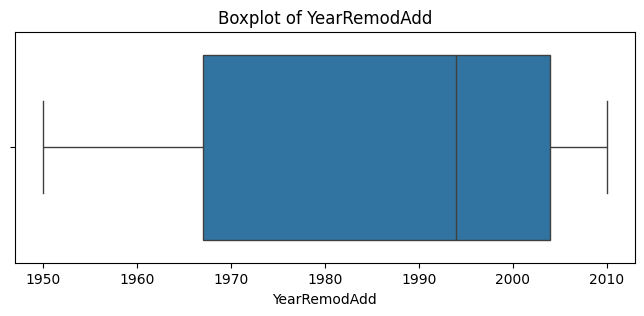

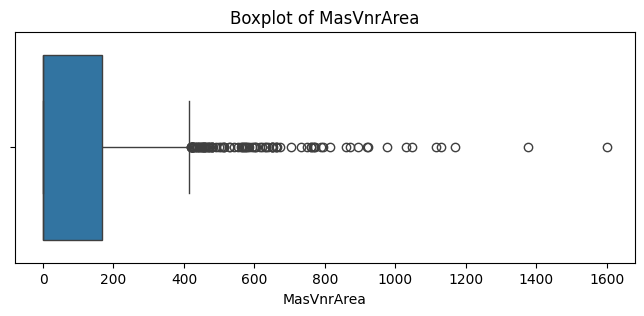

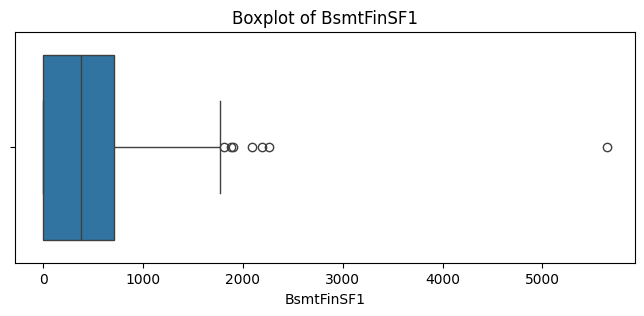

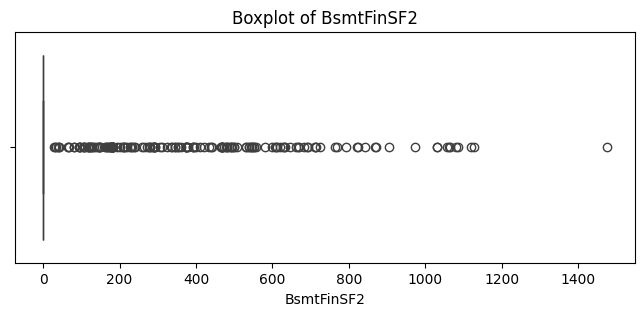

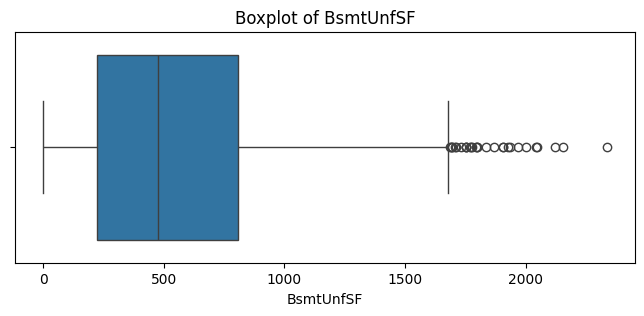

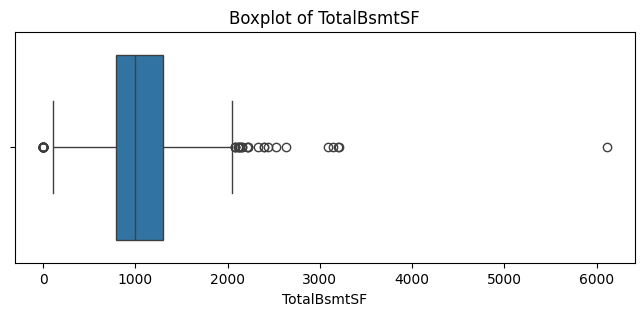

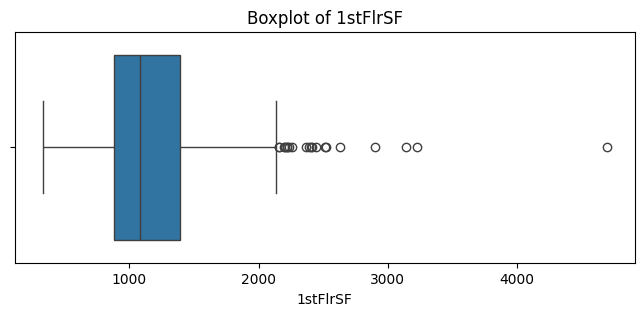

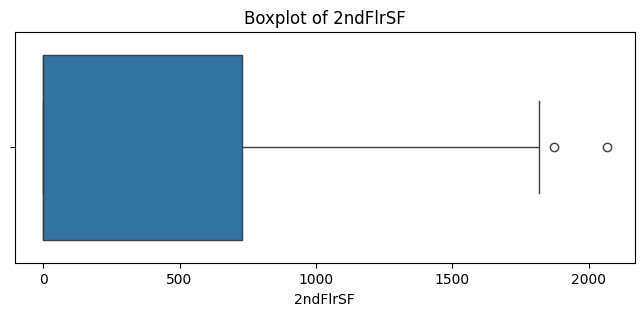

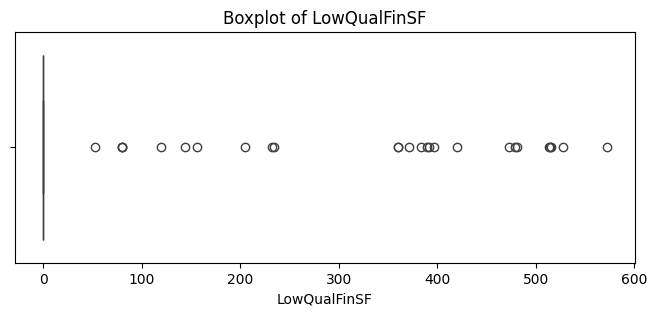

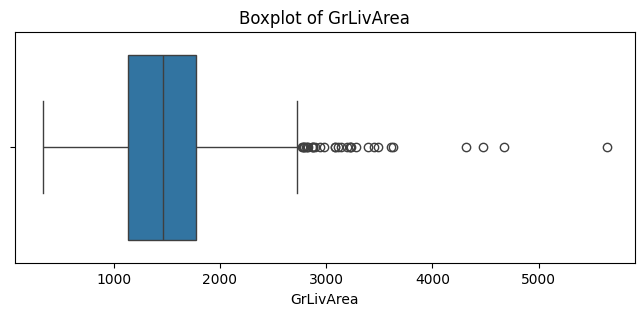

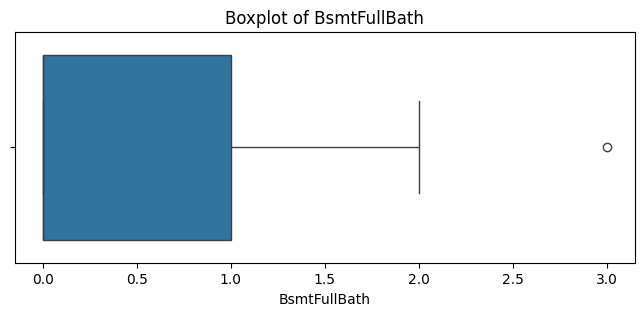

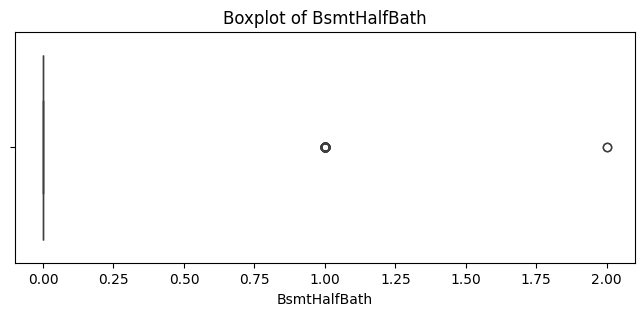

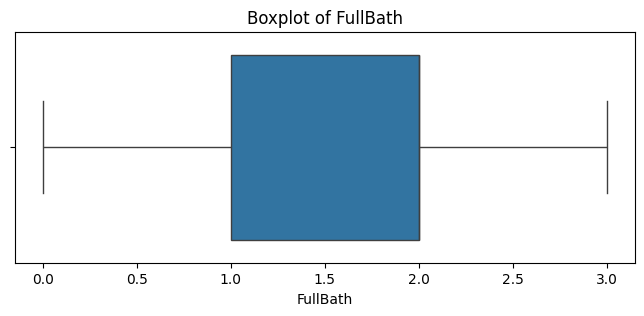

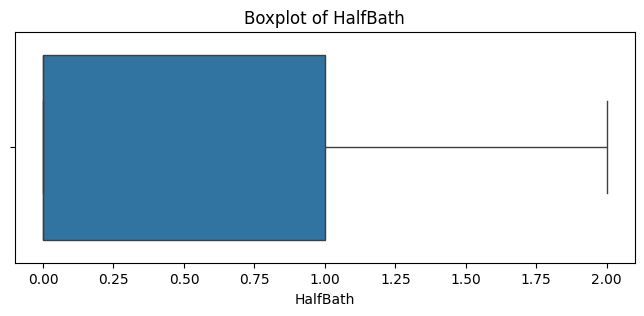

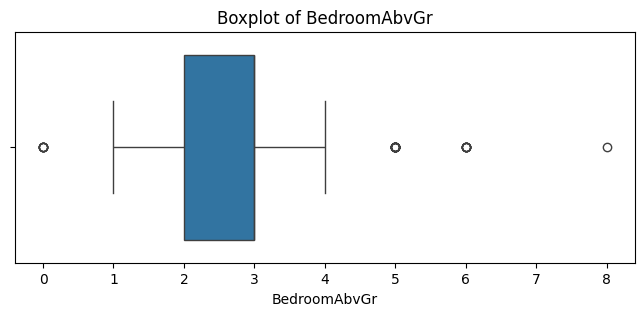

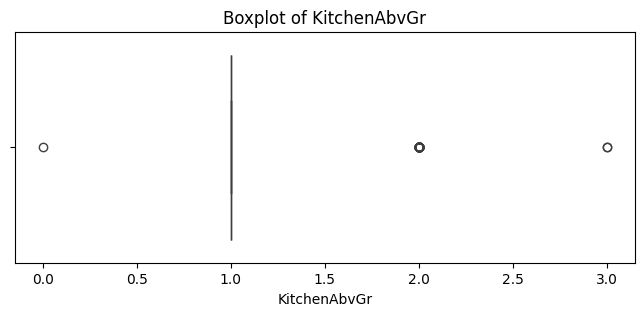

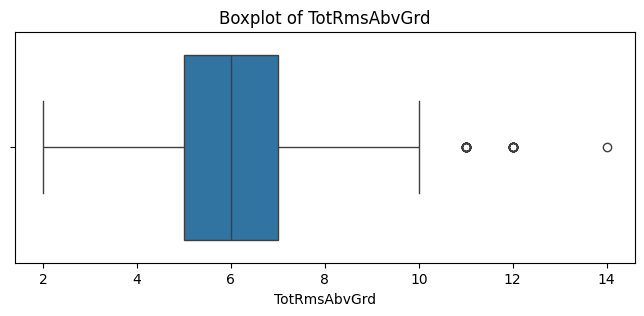

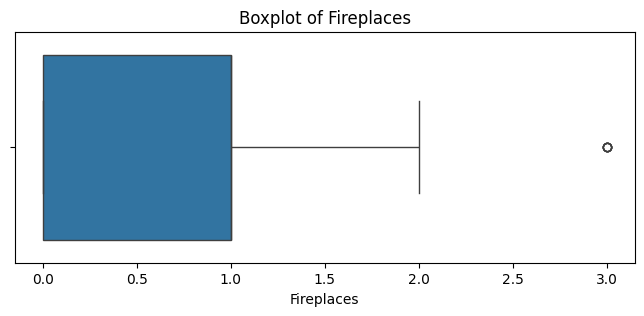

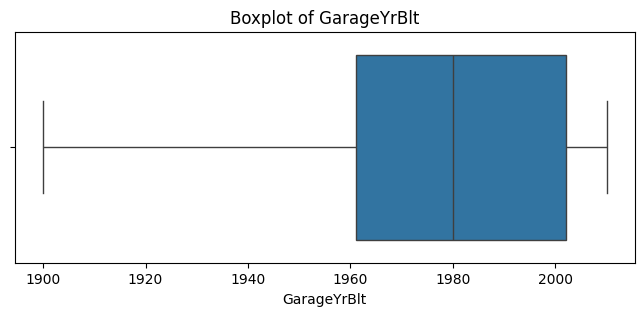

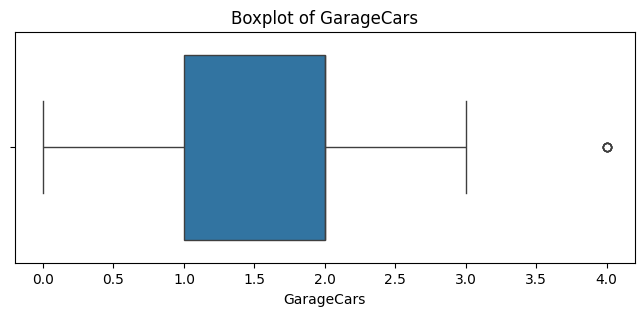

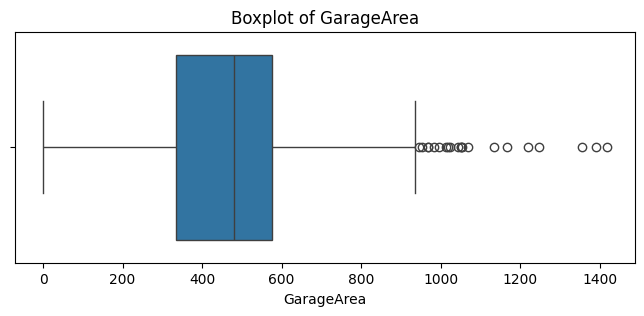

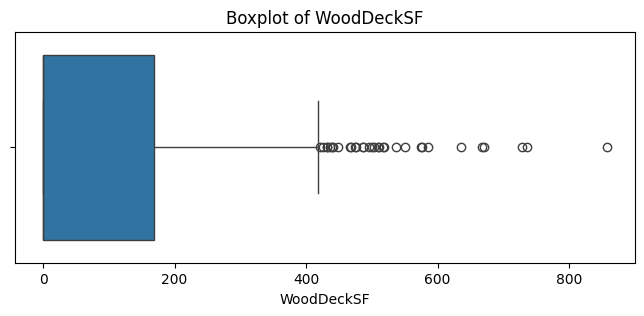

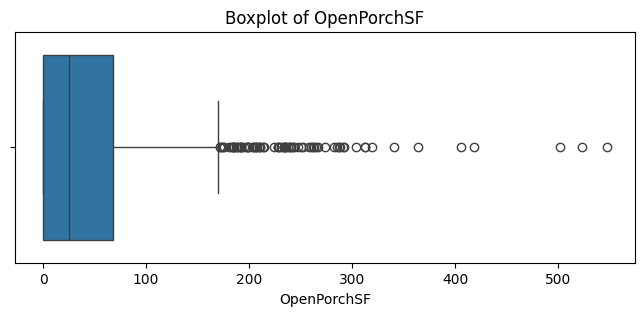

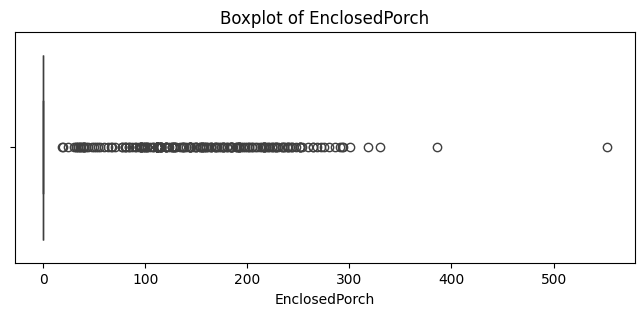

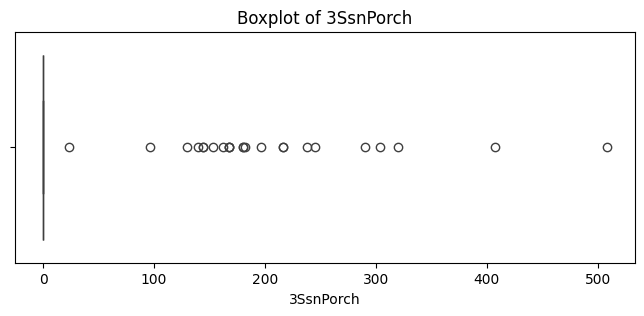

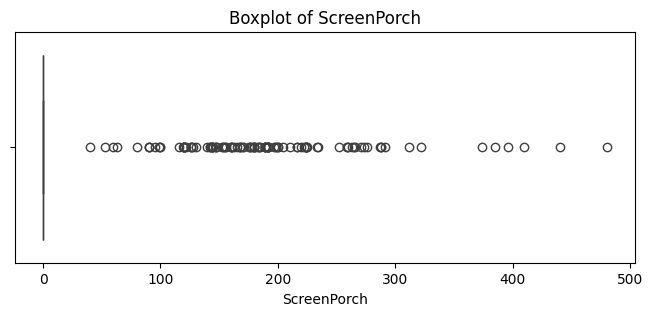

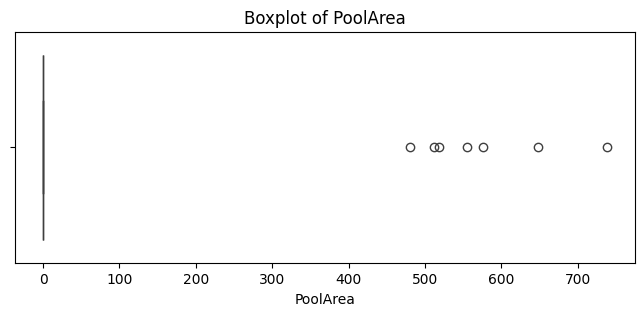

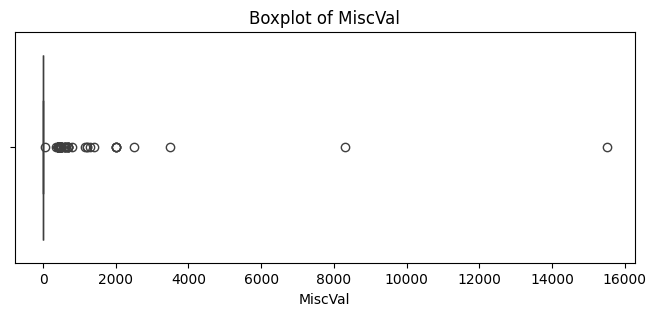

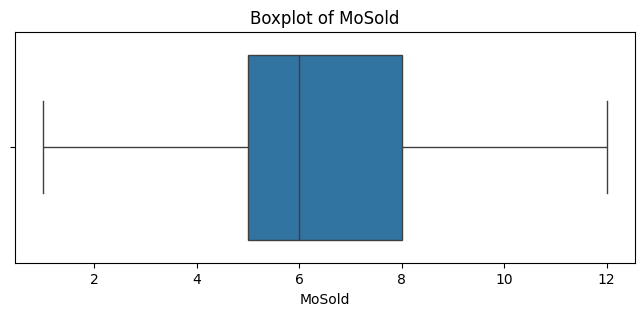

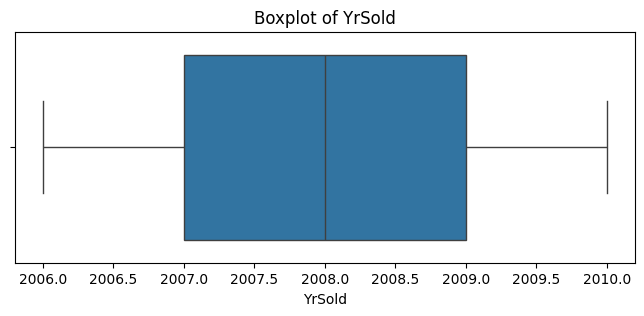

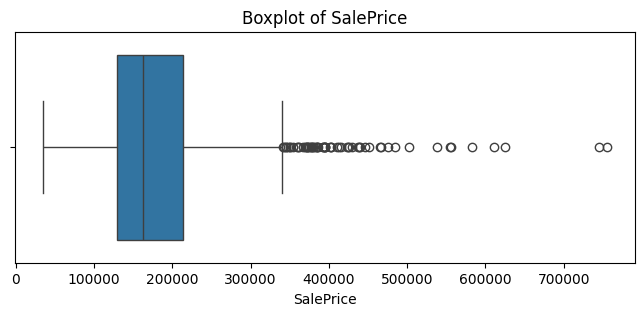

In [45]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

Most of the numerical data have outliers.

In [46]:
# Calculate IQR outliers for every numerical feature

outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df = outlier_summary_df.sort_values(
    by="Outlier Count",
    ascending=False
)

outlier_summary_df

,Feature,Outlier Count,Outlier Percentage
30,EnclosedPorch,208,14.25
10,BsmtFinSF2,167,11.44
5,OverallCond,125,8.56
32,ScreenPorch,116,7.95
1,MSSubClass,103,7.05
8,MasVnrArea,96,6.58
2,LotFrontage,88,6.03
18,BsmtHalfBath,82,5.62
29,OpenPorchSF,77,5.27
3,LotArea,69,4.73


In [47]:
outlier_features = outlier_summary_df[
    outlier_summary_df["Outlier Count"] > 0
]

outlier_features

,Feature,Outlier Count,Outlier Percentage
30,EnclosedPorch,208,14.25
10,BsmtFinSF2,167,11.44
5,OverallCond,125,8.56
32,ScreenPorch,116,7.95
1,MSSubClass,103,7.05
8,MasVnrArea,96,6.58
2,LotFrontage,88,6.03
18,BsmtHalfBath,82,5.62
29,OpenPorchSF,77,5.27
3,LotArea,69,4.73


Boxplots and the IQR method were used to identify outliers in the numerical features. Outliers were found in several features, with the highest numbers in EnclosedPorch, BsmtFinSF2, OverallCond, ScreenPorch, MSSubClass, MasVnrArea, LotFrontage, BsmtHalfBath, OpenPorchSF, LotArea, KitchenAbvGr, TotalBsmtSF, and SalePrice. These values will be investigated further using distribution plots to determine whether they are genuine extreme values or possible data issues.

##### 3.6 Unusual Distributions

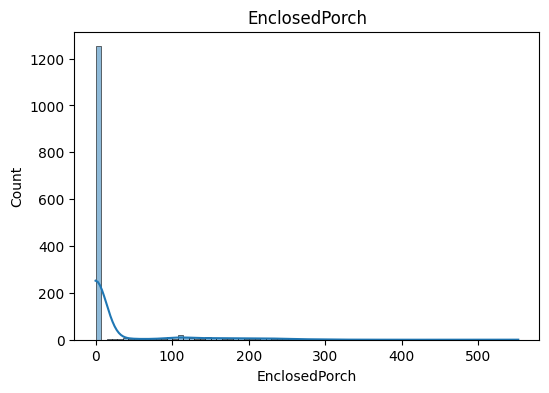

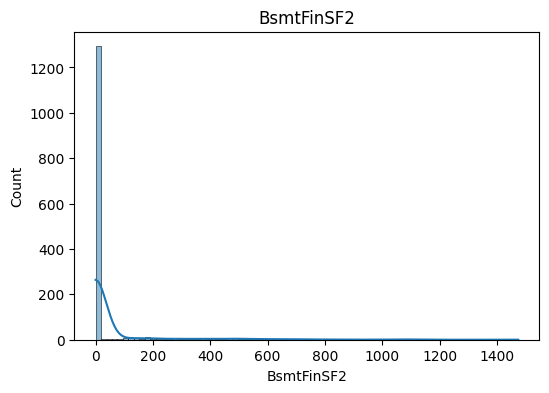

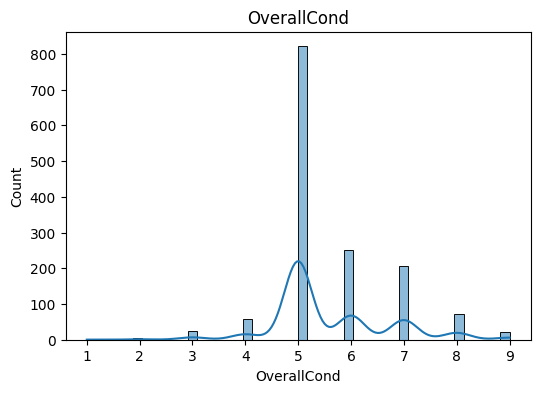

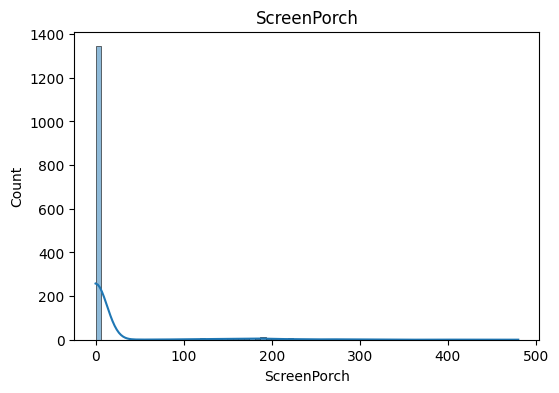

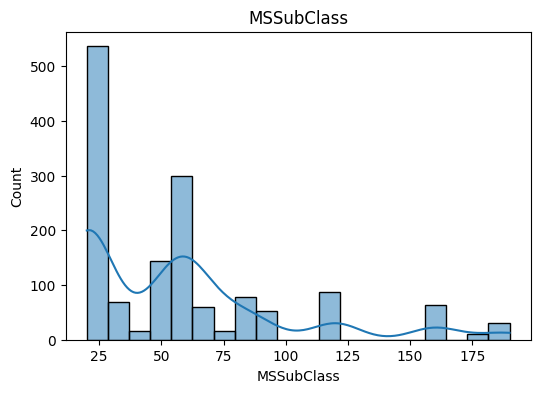

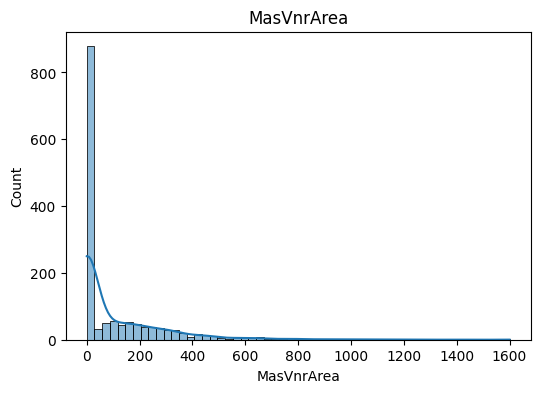

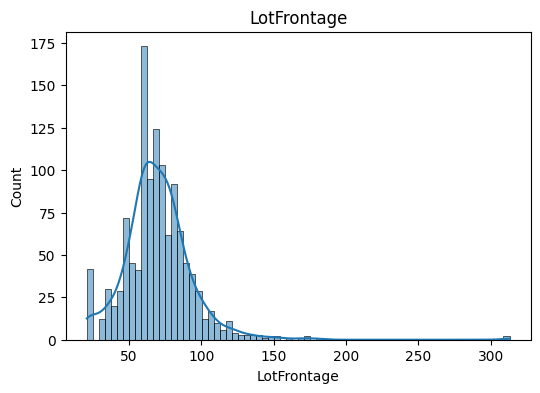

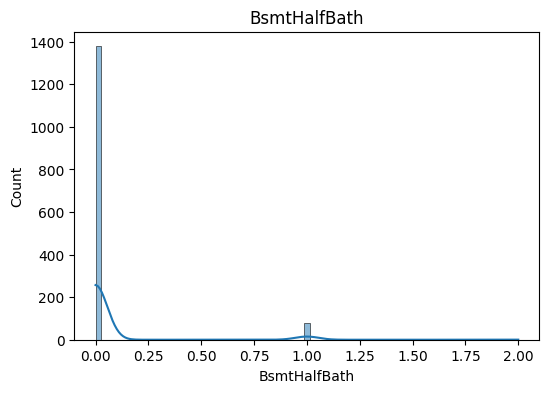

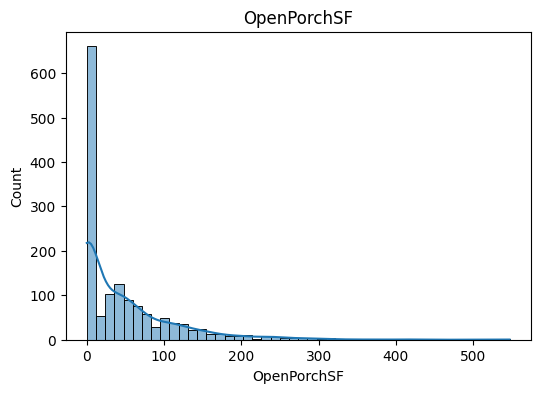

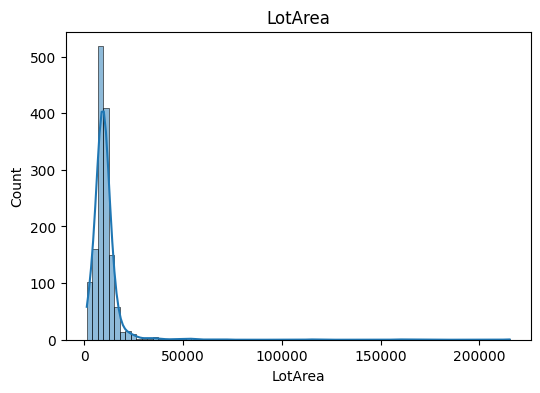

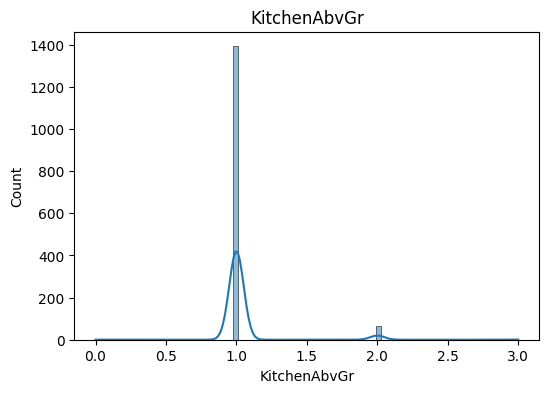

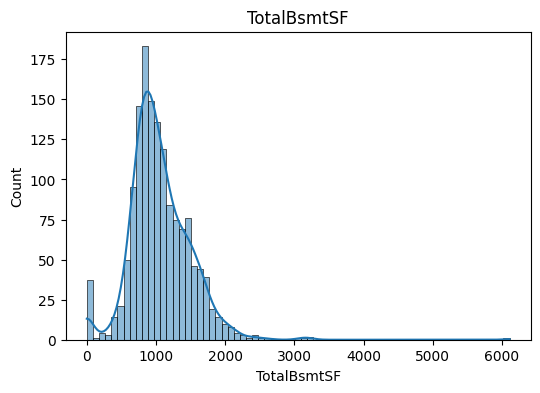

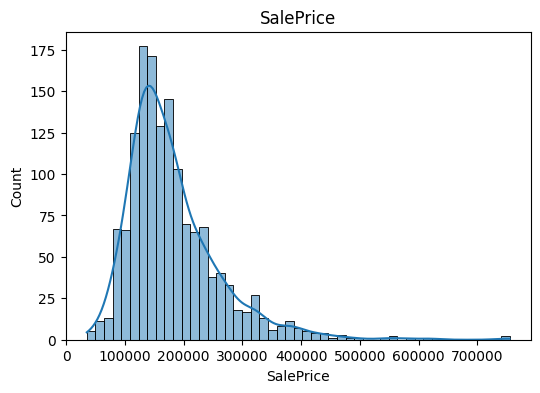

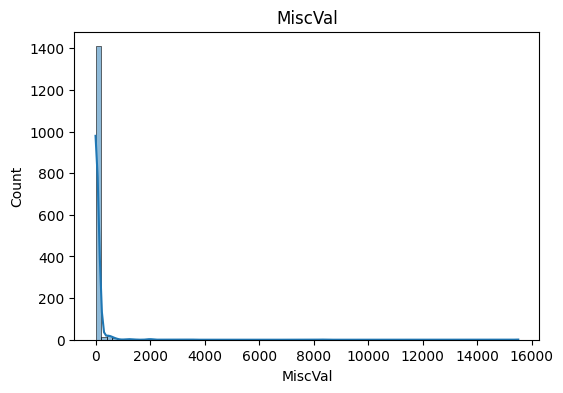

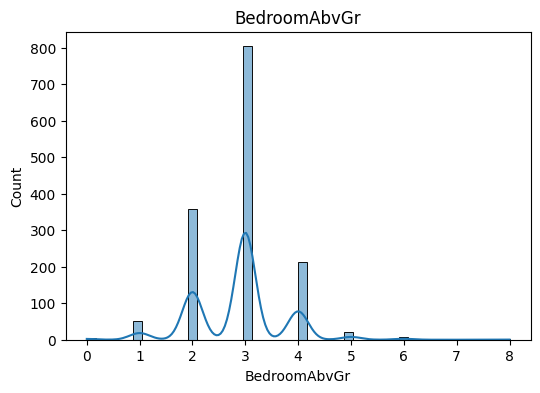

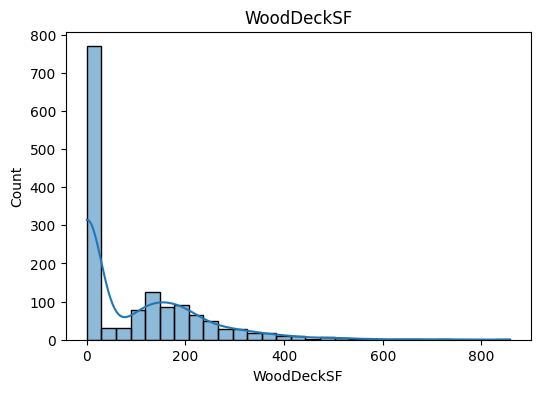

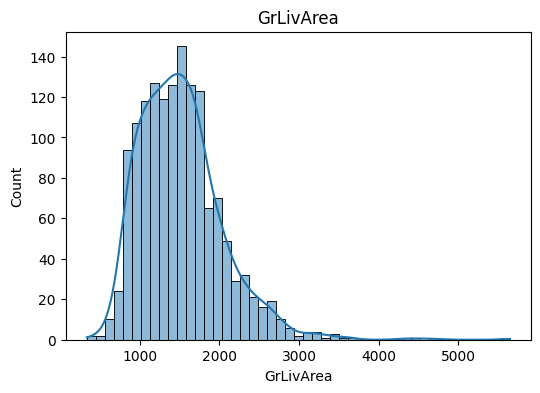

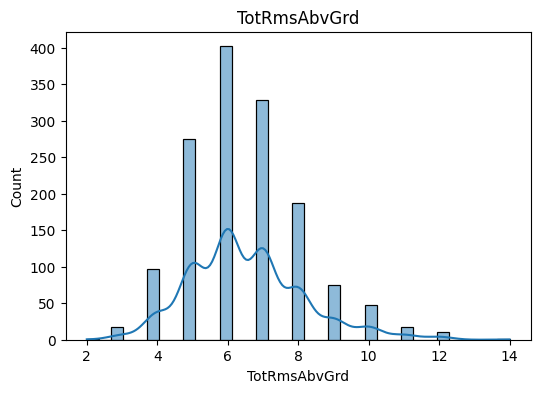

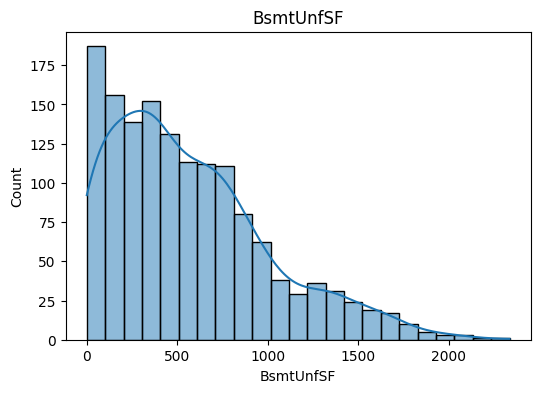

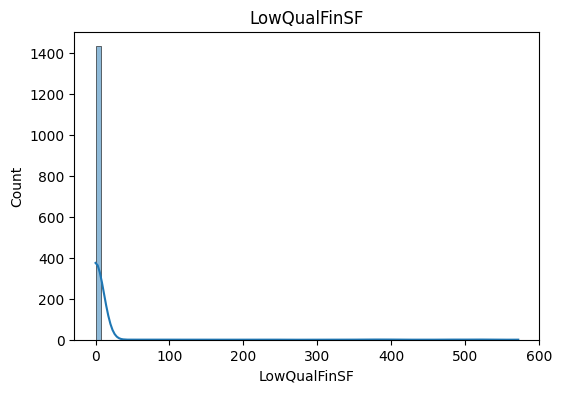

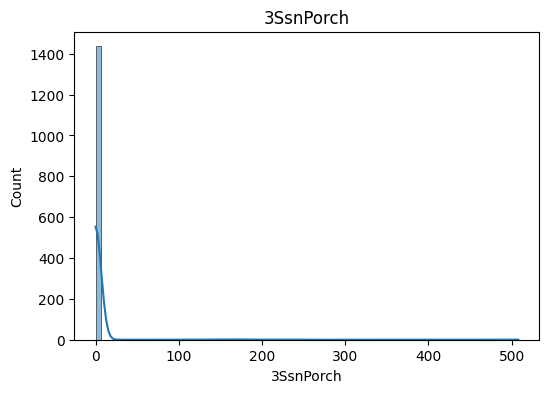

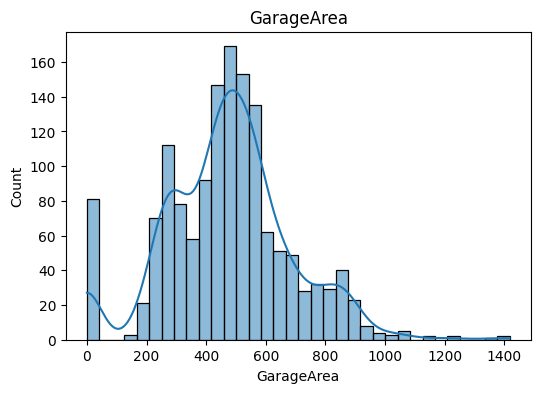

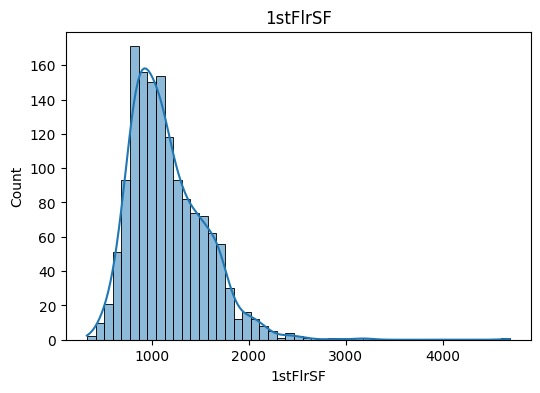

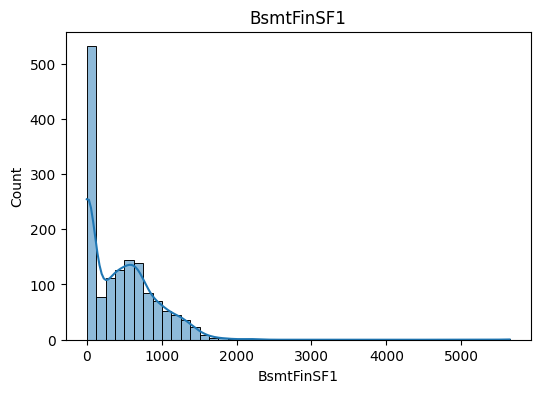

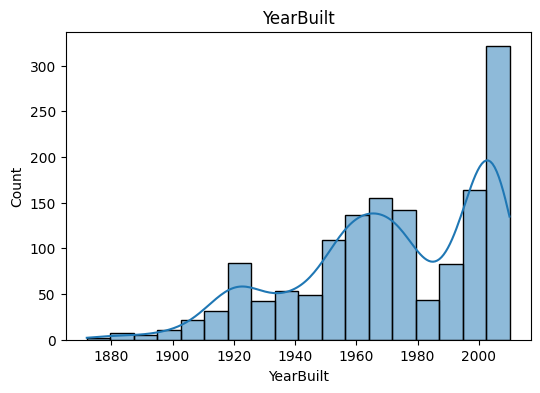

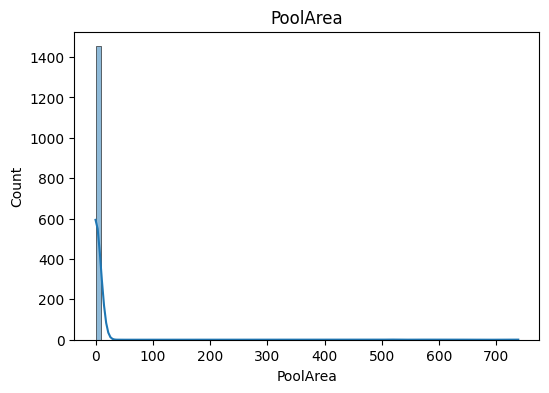

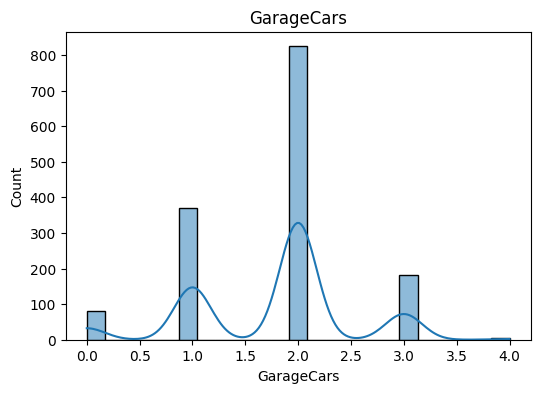

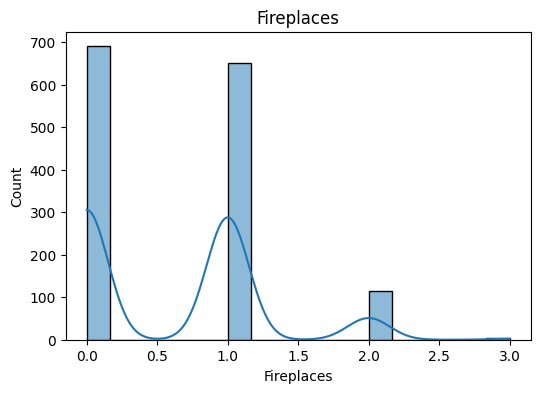

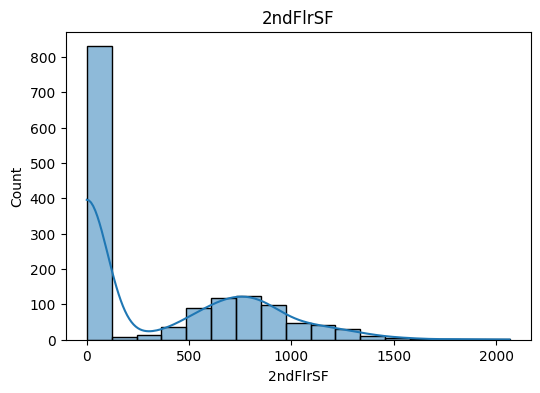

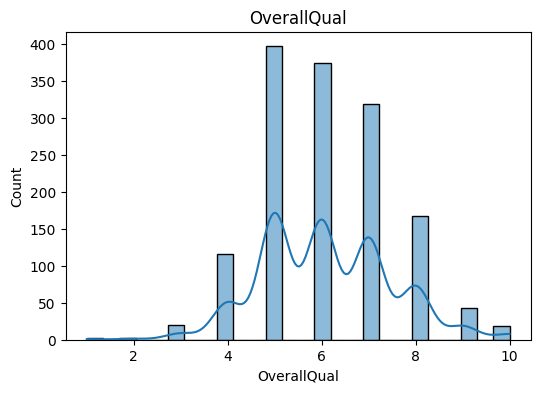

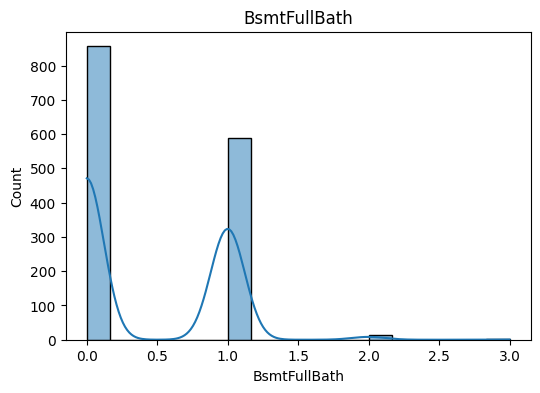

In [48]:
outlier_feature_names = outlier_features["Feature"].tolist()
for col in outlier_feature_names:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Histograms were used to investigate the numerical features that contained IQR outliers. Several features showed right-skewed distributions, where most values are small and a few values are much larger. Some features also contained many zero values, especially features related to optional property areas such as porches, pools, and basement features.

SalePrice, GrLivArea, LotArea, TotalBsmtSF, and several porch/basement features showed noticeable unusual distributions.

These patterns should be considered during preprocessing because highly skewed variables and extreme values may affect the performance of some machine-learning models. The outliers were not removed at this stage because they may represent genuine properties.

##### 3.7 Possible Data Leakage

The training dataset was used for data understanding and EDA, and no test-set information was used to make EDA decisions. Therefore, no possible data leakage was identified at this stage. Data preprocessing and model training will be performed separately after the train-test separation to avoid leakage.

##### Summary

__Missing Values:__
Missing values were identified in 3 numerical features and 16 categorical features. Further investigation showed that the missing values in the numerical features do not represent a meaningful absence, while most missing values in the categorical features have a meaningful interpretation. For example, in some categorical features, a missing value represents the absence of a particular property or facility, such as no basement, no garage, no pool, or no fireplace. Therefore, missing values will not be treated uniformly and will require feature-specific handling during preprocessing.

__Duplicate Values:__
No duplicate records were identified in the dataset. Therefore, no duplicate rows need to be removed during preprocessing.

__Inconsistent Values:__
Some categorical features contain different category labels representing different conditions or levels of the same property characteristic. These values require further investigation to determine whether they represent genuine differences or potential inconsistencies. The category definitions provided in the data dictionary will be used to understand and appropriately handle these values.

__Negative Values:__
No invalid negative values were identified in the numerical features where negative values would not be meaningful. This indicates that there are no obvious negative-value errors requiring correction at this stage.

__Outliers:__
Several numerical features contained potential outliers based on the IQR method. Histograms were therefore used to further investigate the distributions of these features. Several variables showed right-skewed distributions, where most observations had relatively small values while a smaller number of observations had substantially larger values. Some features also contained a large number of zero values, particularly variables related to optional property areas such as porches, pools, and basement features.
SalePrice, GrLivArea, LotArea, TotalBsmtSF, and several porch/basement-related features showed noticeable unusual distributions. Further investigation is required to determine whether the detected outliers are data errors or genuine observations. The outliers will not be automatically removed, because extreme values may represent genuine properties and removing them without sufficient evidence could result in the loss of useful information.

_These findings will be considered during preprocessing because skewed distributions and extreme values may affect the performance of some machine-learning algorithms._

__Data Leakage:__
The training dataset was used for data understanding and EDA, and no test-set information was used to make EDA decisions. Therefore, no data leakage was identified at this stage. Data preprocessing and model training will be performed separately after the train-test separation, with preprocessing steps fitted only on the training data where applicable, to prevent information from the test set from influencing the model.

### 4. Exploratory Data Analysis

#### 4.1 Univariate Analysis

Univariate analysis was conducted to examine each variable individually and understand its distribution, central tendency, variability, and overall behaviour. Different methods were selected based on the variable type. For numerical variables, histograms and boxplots were used to examine distributions, skewness, spread, and potential outliers. For categorical variables, frequency tables, bar charts, and appropriate pie charts were used to examine category frequencies and proportions.

The analysis began with the target variable, SalePrice, to understand its distribution and variability. We then examined important numerical and categorical features identified during the previous data-understanding and EDA stages. For numerical variables, additional attention was given to features that showed unusual distributions, including strong skewness, extreme values, or a large number of zero observations. These features were investigated further because such characteristics may influence preprocessing decisions and the performance of certain machine-learning models.

Categorical variables were examined using frequency-based methods to understand the distribution of their categories, identify dominant or rare categories, and determine whether missing values represented meaningful absence or actual missing information. The results of the univariate analysis were recorded as insights and will be used to support subsequent preprocessing and feature-engineering decisions.

##### 4.1.1 SalePrice Distribution

In [49]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

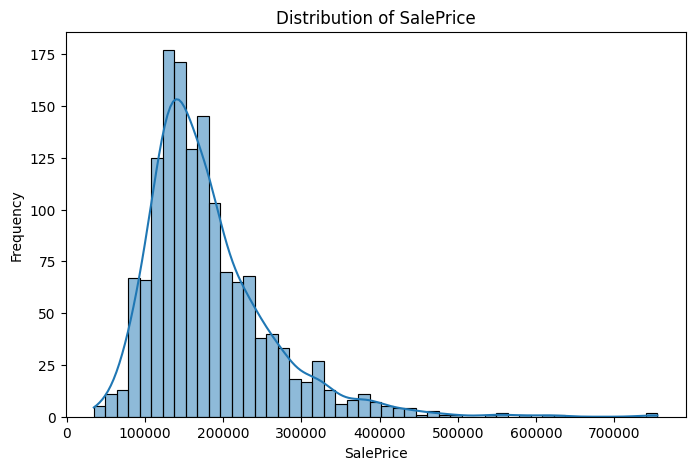

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.show()

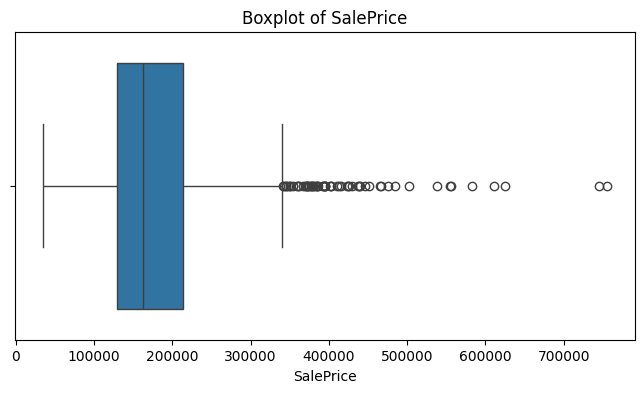

In [51]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot of SalePrice")
plt.xlabel("SalePrice")

plt.show()

_The SalePrice distribution is right-skewed rather than approximately normally distributed. The mean sale price ($180,921.20) is higher than the median ($163,000), which is consistent with the right-skewed distribution. The data contains high-priced properties, with a maximum SalePrice of $755,000. The boxplot also shows several observations beyond the upper whisker, indicating potential outliers._

In [52]:
important_features = [
    # House / Property Characteristics
    "LotFrontage",
    "LotArea",
    "LotShape",
    "LandContour",
    "LandSlope",
    "LotConfig",
    "BldgType",
    "HouseStyle",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "1stFlrSF",
    "2ndFlrSF",
    "GrLivArea",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",

    # Basement Features
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",

    # Garage Features
    "GarageType",
    "GarageYrBlt",
    "GarageFinish",
    "GarageCars",
    "GarageArea",
    "GarageQual",
    "GarageCond",

    # House Systems / Utilities
    "Heating",
    "HeatingQC",
    "CentralAir",
    "Electrical",
    "Utilities",

    # Exterior / Construction
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "MasVnrArea",
    "ExterQual",
    "ExterCond",
    "Foundation",

    # Outdoor Features
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "PoolQC",
    "Fence",
    "MiscFeature",
    "MiscVal",

    # Location / Access
    "MSZoning",
    "Street",
    "Alley",
    "Neighborhood",
    "Condition1",
    "Condition2",

    # Sale / Transaction
    "MoSold",
    "YrSold",
    "SaleType",
    "SaleCondition"
]

In [53]:
important_numerical = df[important_features].select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

important_categorical = df[important_features].select_dtypes(
    include=["object"]
).columns.tolist()

C:\Users\dampa\AppData\Local\Temp\ipykernel_3700\3912256207.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  important_categorical = df[important_features].select_dtypes(


##### 4.1.2 Important Numerical Features

In [54]:
print("Numerical Features:")
print(important_numerical)
print("Numerical variables count:", len(important_numerical))

Numerical Features:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'MasVnrArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Numerical variables count: 33


In [55]:
df[important_numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0
2ndFlrSF,1460.0,346.992466,436.528436,0.0,0.00,0.0,728.00,2065.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
BedroomAbvGr,1460.0,2.866438,0.815778,0.0,2.00,3.0,3.00,8.0


The numerical variables have different scales and levels of variability. Several features contain many zero values, especially optional property features such as porches, pools, and some basement features. Some variables have very large maximum values compared with their median values, suggesting skewed distributions and possible extreme observations. SalePrice also has a wide range, indicating considerable variation in house prices.

In [56]:
skewness = df[important_numerical].skew().sort_values(ascending=False)

skewness

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -0.649415
dtype: float64

In [57]:
highly_skewed = skewness[abs(skewness) > 1]

print("Highly skewed features:")
print(highly_skewed)

Highly skewed features:
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
1stFlrSF          1.376757
GrLivArea         1.366560
dtype: float64


In [58]:
zero_percentage = (
    (df[important_numerical] == 0).sum() / len(df) * 100
).sort_values(ascending=False)

many_zeros = zero_percentage[zero_percentage > 50]

print("Features with more than 50% zero values:")
print(many_zeros)

Features with more than 50% zero values:
PoolArea         99.520548
3SsnPorch        98.356164
MiscVal          96.438356
BsmtHalfBath     94.383562
ScreenPorch      92.054795
BsmtFinSF2       88.561644
EnclosedPorch    85.753425
HalfBath         62.534247
MasVnrArea       58.972603
BsmtFullBath     58.630137
2ndFlrSF         56.780822
WoodDeckSF       52.123288
dtype: float64


In [59]:
unusual_features = set(highly_skewed.index).union(
    set(many_zeros.index)
)

unusual_features = list(unusual_features)

print("Number of unusual distribution features:",
      len(unusual_features))

print("\nUnusual distribution features:")
print(unusual_features)

Number of unusual distribution features: 20

Unusual distribution features:
['HalfBath', 'EnclosedPorch', 'BsmtFinSF1', 'MiscVal', 'BsmtFinSF2', 'TotalBsmtSF', 'BsmtHalfBath', 'KitchenAbvGr', 'BsmtFullBath', 'MasVnrArea', 'GrLivArea', 'OpenPorchSF', 'ScreenPorch', '1stFlrSF', 'PoolArea', 'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'LotArea', '3SsnPorch']


Feature: HalfBath
Mean     : 0.38
Median   : 0.00
Mode     : 0.00
Variance : 0.25
Skewness : 0.68


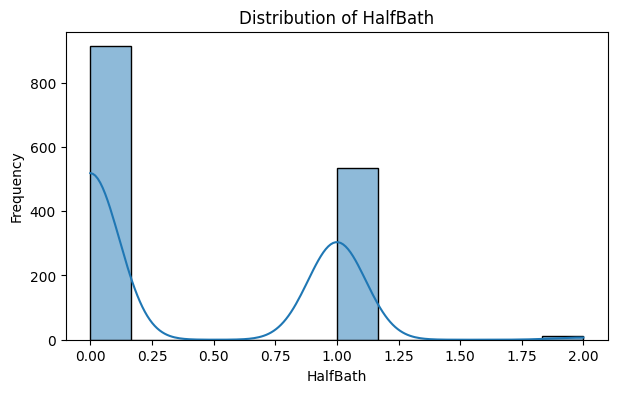

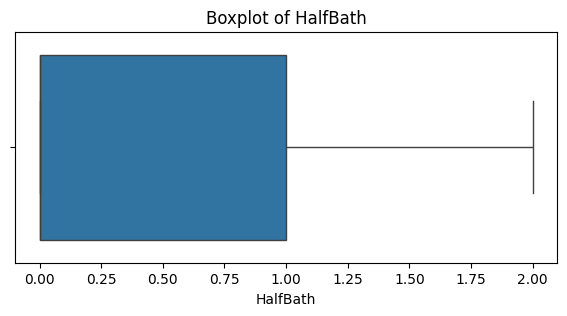

Feature: EnclosedPorch
Mean     : 21.95
Median   : 0.00
Mode     : 0.00
Variance : 3735.55
Skewness : 3.09


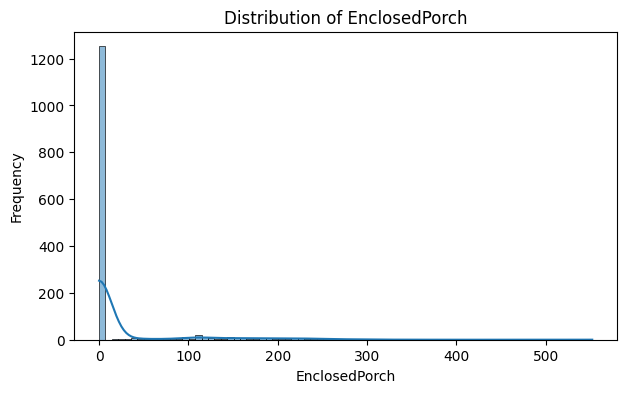

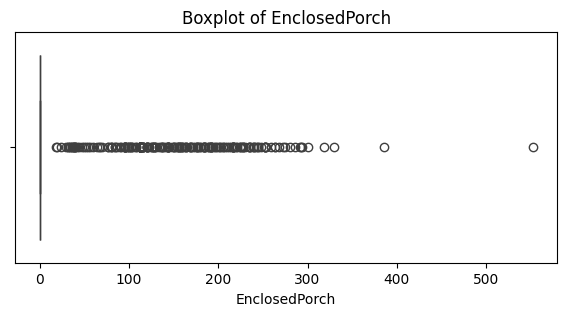

Feature: BsmtFinSF1
Mean     : 443.64
Median   : 383.50
Mode     : 0.00
Variance : 208025.47
Skewness : 1.69


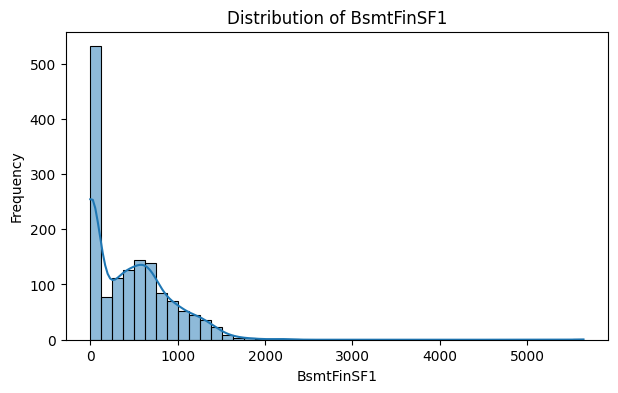

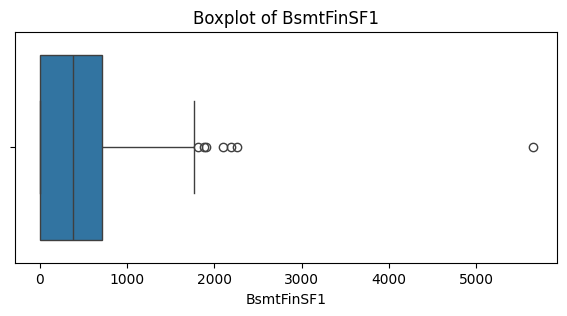

Feature: MiscVal
Mean     : 43.49
Median   : 0.00
Mode     : 0.00
Variance : 246138.06
Skewness : 24.48


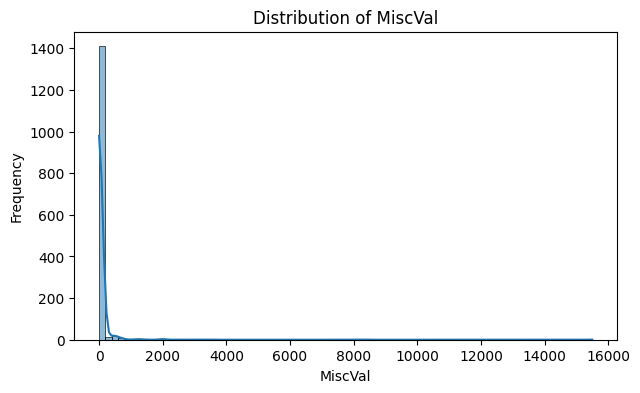

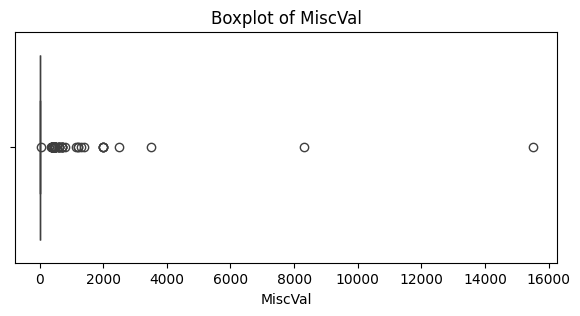

Feature: BsmtFinSF2
Mean     : 46.55
Median   : 0.00
Mode     : 0.00
Variance : 26023.91
Skewness : 4.26


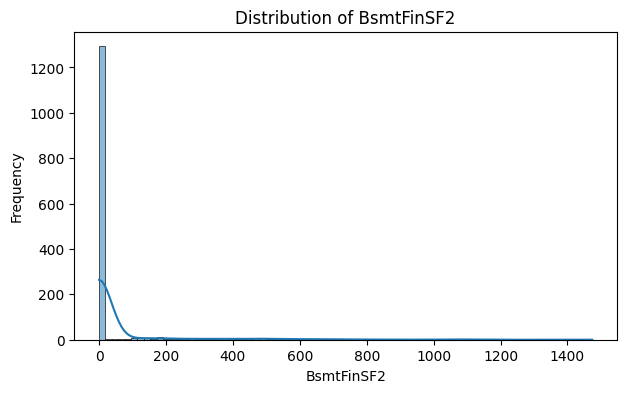

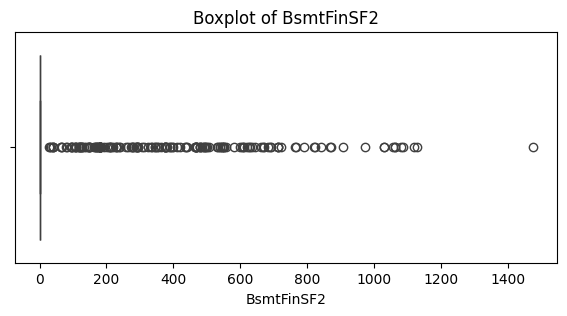

Feature: TotalBsmtSF
Mean     : 1057.43
Median   : 991.50
Mode     : 0.00
Variance : 192462.36
Skewness : 1.52


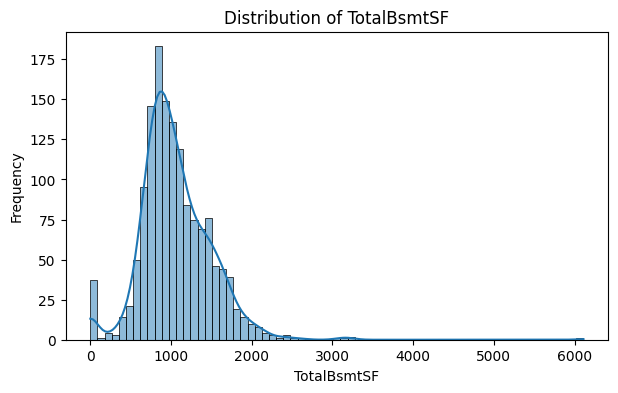

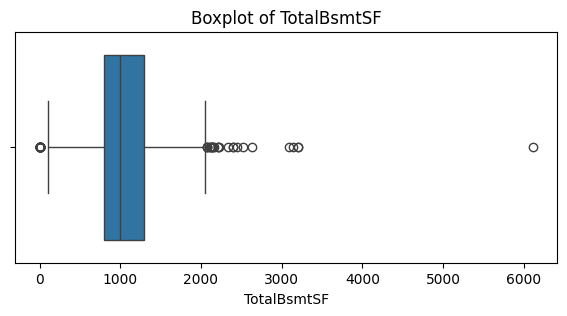

Feature: BsmtHalfBath
Mean     : 0.06
Median   : 0.00
Mode     : 0.00
Variance : 0.06
Skewness : 4.10


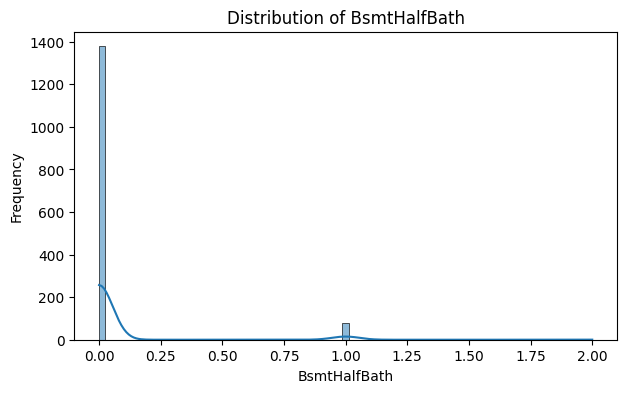

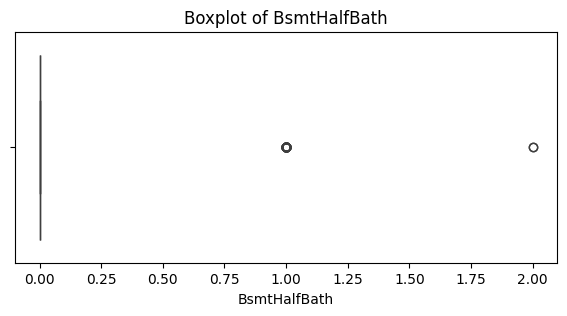

Feature: KitchenAbvGr
Mean     : 1.05
Median   : 1.00
Mode     : 1.00
Variance : 0.05
Skewness : 4.49


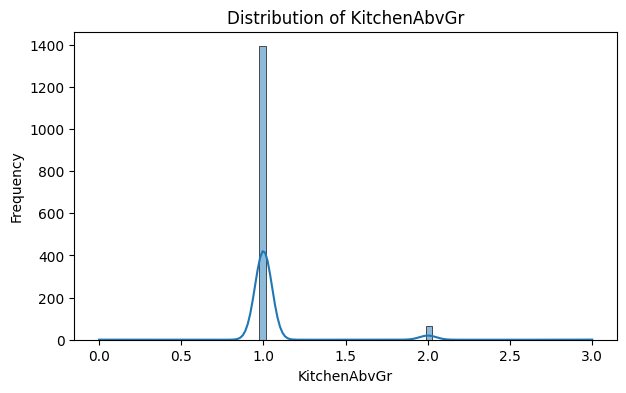

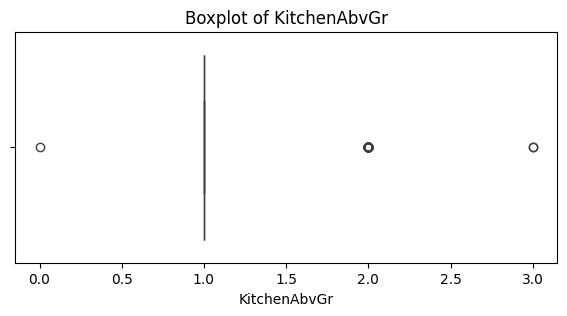

Feature: BsmtFullBath
Mean     : 0.43
Median   : 0.00
Mode     : 0.00
Variance : 0.27
Skewness : 0.60


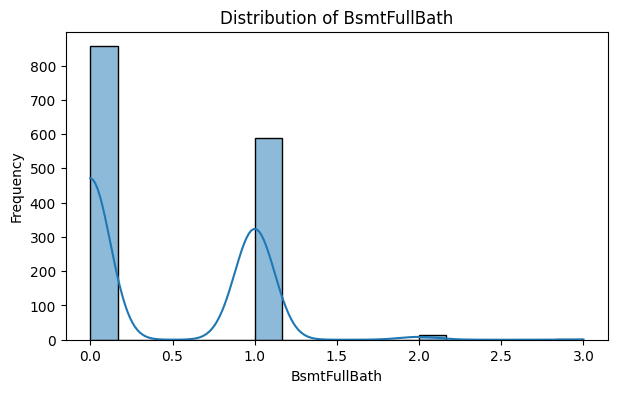

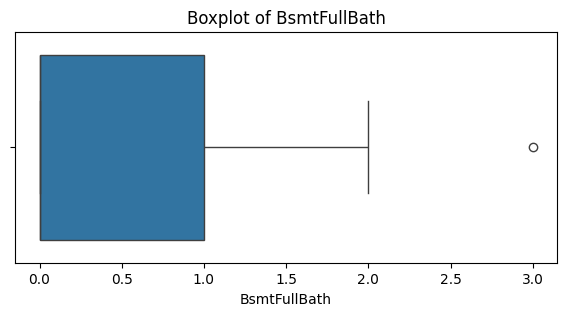

Feature: MasVnrArea
Mean     : 103.69
Median   : 0.00
Mode     : 0.00
Variance : 32784.97
Skewness : 2.67


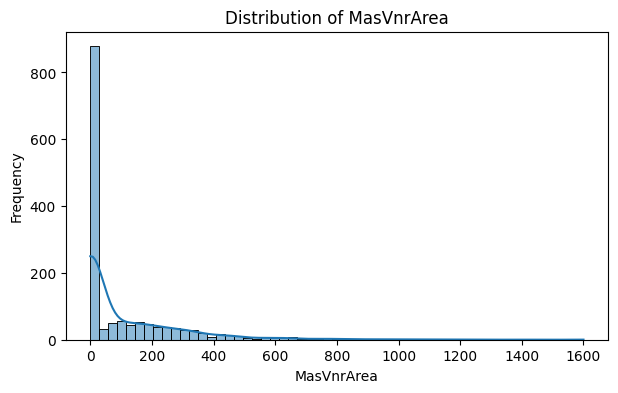

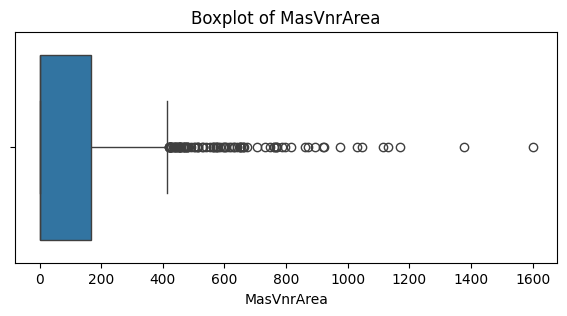

Feature: GrLivArea
Mean     : 1515.46
Median   : 1464.00
Mode     : 864.00
Variance : 276129.63
Skewness : 1.37


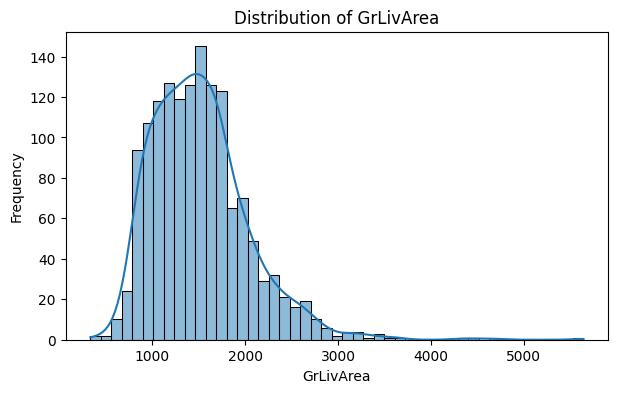

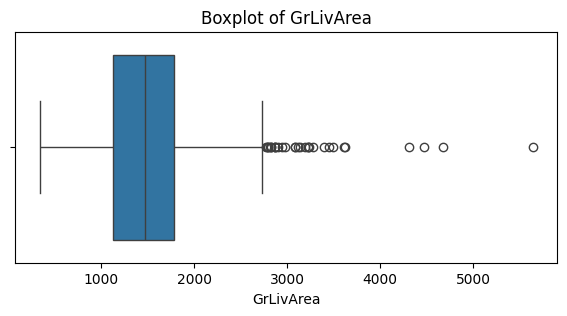

Feature: OpenPorchSF
Mean     : 46.66
Median   : 25.00
Mode     : 0.00
Variance : 4389.86
Skewness : 2.36


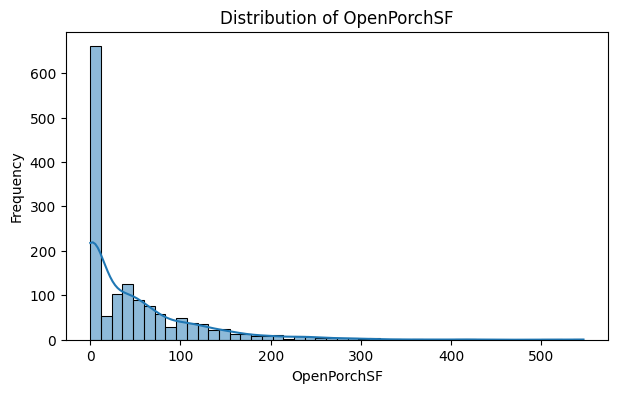

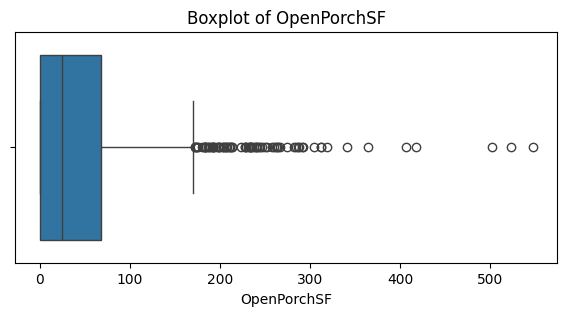

Feature: ScreenPorch
Mean     : 15.06
Median   : 0.00
Mode     : 0.00
Variance : 3108.89
Skewness : 4.12


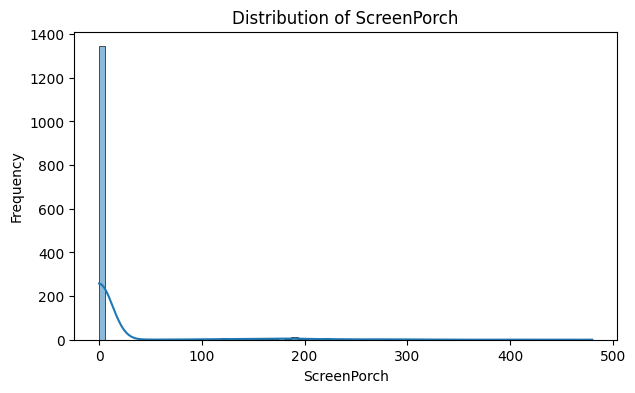

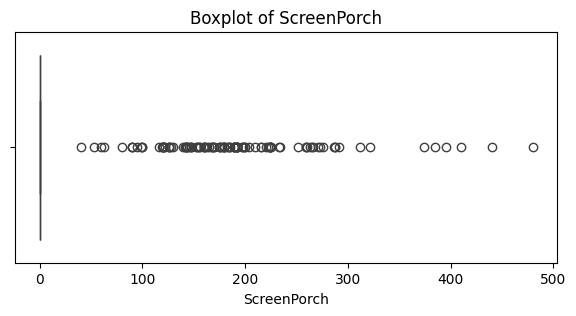

Feature: 1stFlrSF
Mean     : 1162.63
Median   : 1087.00
Mode     : 864.00
Variance : 149450.08
Skewness : 1.38


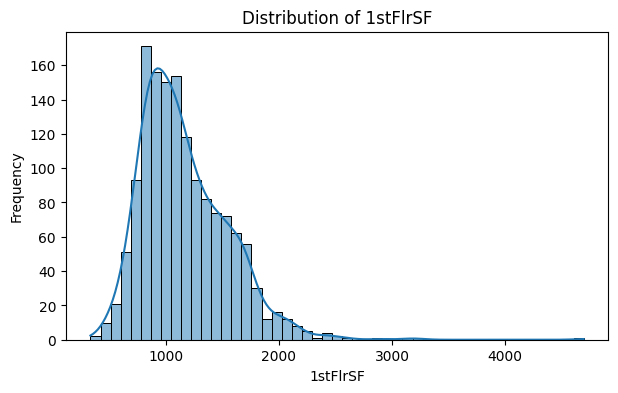

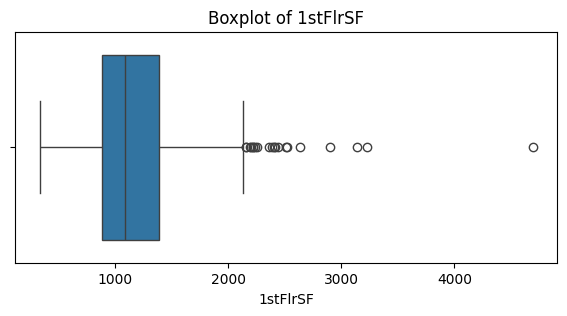

Feature: PoolArea
Mean     : 2.76
Median   : 0.00
Mode     : 0.00
Variance : 1614.22
Skewness : 14.83


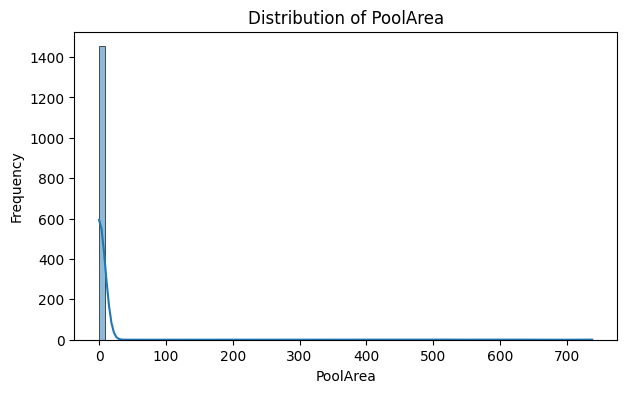

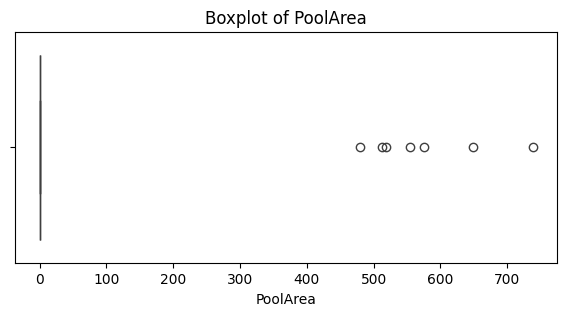

Feature: LotFrontage
Mean     : 70.05
Median   : 69.00
Mode     : 60.00
Variance : 589.75
Skewness : 2.16


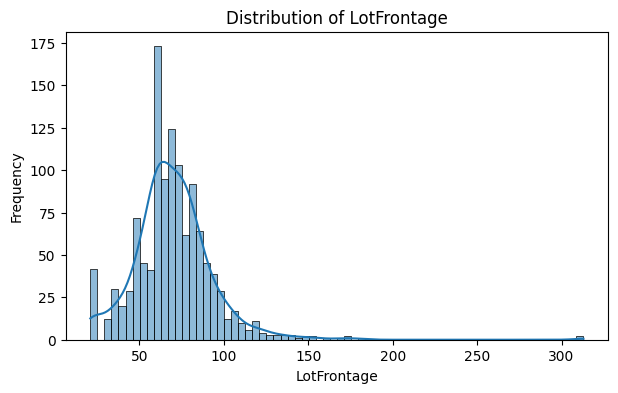

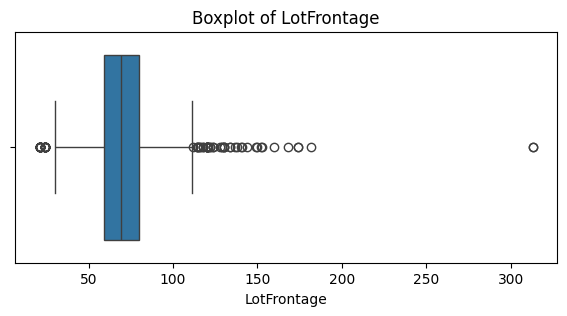

Feature: WoodDeckSF
Mean     : 94.24
Median   : 0.00
Mode     : 0.00
Variance : 15709.81
Skewness : 1.54


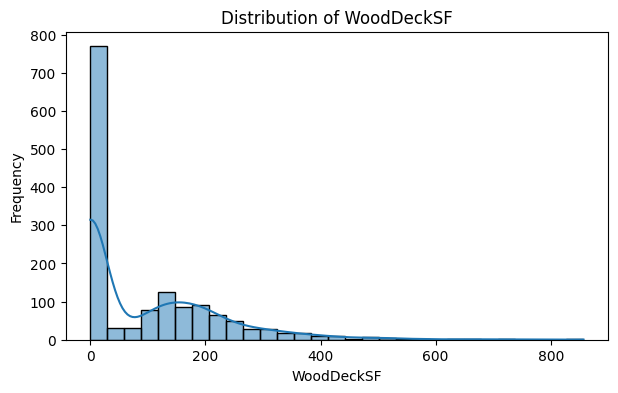

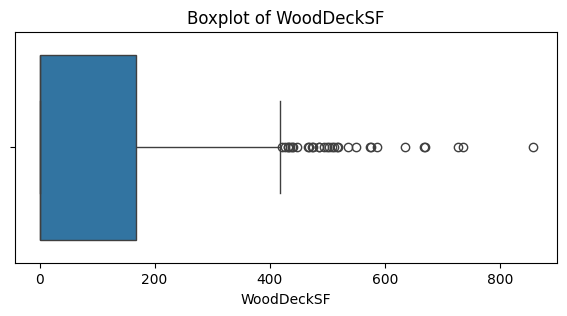

Feature: 2ndFlrSF
Mean     : 346.99
Median   : 0.00
Mode     : 0.00
Variance : 190557.08
Skewness : 0.81


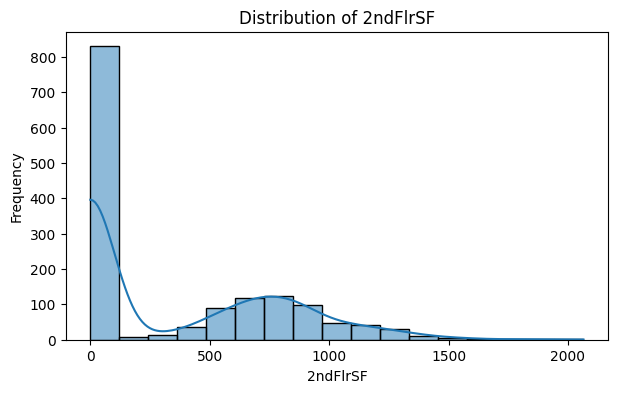

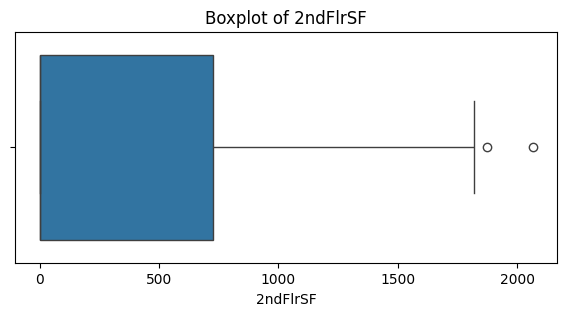

Feature: LotArea
Mean     : 10516.83
Median   : 9478.50
Mode     : 7200.00
Variance : 99625649.65
Skewness : 12.21


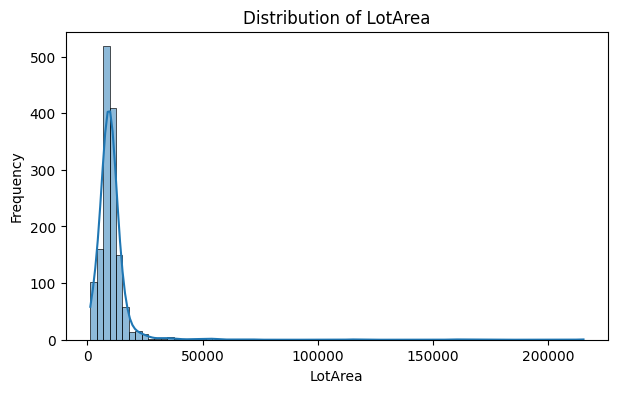

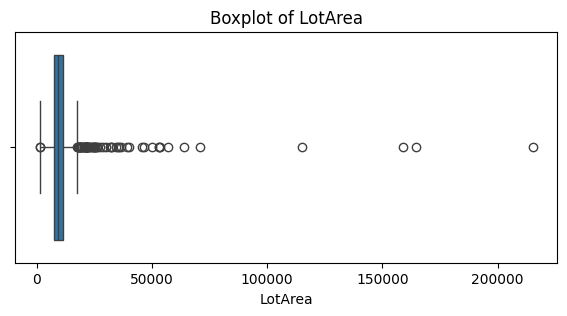

Feature: 3SsnPorch
Mean     : 3.41
Median   : 0.00
Mode     : 0.00
Variance : 859.51
Skewness : 10.30


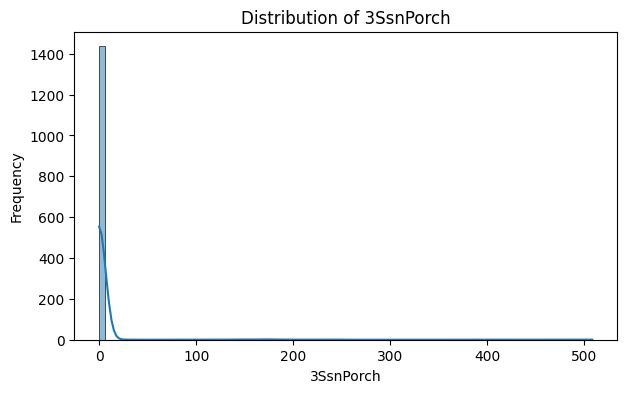

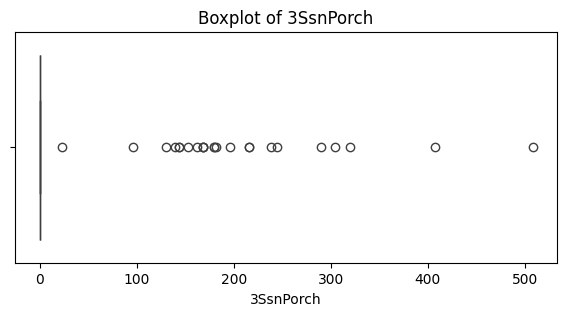

In [60]:
for col in unusual_features:

    # Statistics
    mean_value = df[col].mean()
    median_value = df[col].median()
    mode_value = df[col].mode()[0]
    variance_value = df[col].var()
    skewness_value = df[col].skew()

    print("=" * 60)
    print(f"Feature: {col}")
    print(f"Mean     : {mean_value:.2f}")
    print(f"Median   : {median_value:.2f}")
    print(f"Mode     : {mode_value:.2f}")
    print(f"Variance : {variance_value:.2f}")
    print(f"Skewness : {skewness_value:.2f}")

    # Histogram
    plt.figure(figsize=(7, 4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

    # Boxplot
    plt.figure(figsize=(7, 3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

| Feature | Mean | Median | Mode | Variance | Skewness | Observation |
|---|---:|---:|---:|---:|---:|---|
| `LotFrontage` | 70.05 | 69.00 | 60.00 | 589.75 | 2.16 | The distribution is strongly right-skewed, with several potential high-value outliers. |
| `OpenPorchSF` | 46.66 | 25.00 | 0.00 | 4389.86 | 2.36 | Many properties have no open porch. The distribution is right-skewed with several potential outliers. |
| `2ndFlrSF` | 346.99 | 0.00 | 0.00 | 190557.08 | 0.81 | Many properties have no second floor. The distribution is right-skewed with some high values. |
| `BsmtFinSF1` | 443.64 | 383.50 | 0.00 | 208025.47 | 1.69 | Many properties have no finished basement area of this type. The distribution is right-skewed with potential outliers. |
| `3SsnPorch` | 3.41 | 0.00 | 0.00 | 859.51 | 10.30 | Most properties have no three-season porch. A few large values cause strong right-skewness and outliers. |
| `ScreenPorch` | 15.06 | 0.00 | 0.00 | 3108.89 | 4.12 | Most properties have no screen porch. A few larger values cause strong right-skewness and outliers. |
| `KitchenAbvGr` | 1.05 | 1.00 | 1.00 | 0.05 | 4.49 | Most properties have one kitchen. A small number have more, causing right-skewness. |
| `PoolArea` | 2.76 | 0.00 | 0.00 | 1614.22 | 14.83 | Almost all properties have no pool. A few properties have pools, causing strong skewness and outliers. |
| `MiscVal` | 43.49 | 0.00 | 0.00 | 246138.06 | 24.48 | Most properties have no miscellaneous value. A few very large values cause extreme right-skewness and outliers. |
| `TotalBsmtSF` | 1057.43 | 991.50 | 0.00 | 192462.36 | 1.52 | The distribution is right-skewed, with some properties having very large basement areas and potential outliers. |
| `LotArea` | 10516.83 | 9478.50 | 7200.00 | 99625649.65 | 12.21 | The distribution is strongly right-skewed, with a few extremely large lot areas and potential outliers. |
| `EnclosedPorch` | 21.95 | 0.00 | 0.00 | 3735.55 | 3.09 | Most properties have no enclosed porch. The distribution is strongly right-skewed with potential outliers. |
| `WoodDeckSF` | 94.24 | 0.00 | 0.00 | 15709.81 | 1.54 | Many properties have no wood deck. The distribution is right-skewed with several potential outliers. |
| `HalfBath` | 0.38 | 0.00 | 0.00 | 0.25 | 0.68 | Most properties have no half bathroom. Values are mainly concentrated around 0 and 1. |
| `BsmtFullBath` | 0.43 | 0.00 | 0.00 | 0.27 | 0.60 | Many properties have no basement full bathroom. Values are mainly concentrated around 0 and 1. |
| `GrLivArea` | 1515.46 | 1464.00 | 864.00 | 276129.63 | 1.37 | The distribution is right-skewed, with some properties having very large living areas and potential outliers. |
| `BsmtFinSF2` | 46.55 | 0.00 | 0.00 | 26023.91 | 4.26 | Most properties have no finished basement area of this type. A few large values cause strong right-skewness and outliers. |
| `BsmtHalfBath` | 0.06 | 0.00 | 0.00 | 0.06 | 4.10 | Almost all properties have no basement half bathroom. A few values cause strong right-skewness and potential outliers. |
| `MasVnrArea` | 103.69 | 0.00 | 0.00 | 32784.97 | 2.67 | Many properties have no masonry veneer. The distribution is strongly right-skewed with potential outliers. |
| `1stFlrSF` | 1162.63 | 1087.00 | 864.00 | 149450.08 | 1.38 | The distribution is moderately right-skewed, with some large first-floor areas and potential outliers. |

##### 4.1.3 Important Categorical Features

In [61]:
print("\nCategorical Features:")
print(important_categorical)
print("Number of categorical features:", len(important_categorical))


Categorical Features:
['LotShape', 'LandContour', 'LandSlope', 'LotConfig', 'BldgType', 'HouseStyle', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Utilities', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'PoolQC', 'Fence', 'MiscFeature', 'MSZoning', 'Street', 'Alley', 'Neighborhood', 'Condition1', 'Condition2', 'SaleType', 'SaleCondition']
Number of categorical features: 39


In [62]:
df[important_categorical].nunique().sort_values()

Utilities         2
CentralAir        2
Alley             2
Street            2
MasVnrType        3
PoolQC            3
LandSlope         3
GarageFinish      3
BsmtQual          4
MiscFeature       4
Fence             4
ExterQual         4
BsmtExposure      4
BsmtCond          4
LandContour       4
LotShape          4
Electrical        5
ExterCond         5
MSZoning          5
HeatingQC         5
BldgType          5
GarageCond        5
GarageQual        5
LotConfig         5
Foundation        6
Heating           6
BsmtFinType2      6
RoofStyle         6
GarageType        6
SaleCondition     6
BsmtFinType1      6
HouseStyle        8
RoofMatl          8
Condition2        8
SaleType          9
Condition1        9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

| Category Range | Number of Features | Examples |
| -------- | -------- | -------- | 
| 2 | 4 | Utilities, CentralAir, Alley, Street |
| 3–4 | 6 | MasVnrType, PoolQC, LandSlope, GarageFinish,... |
| 5-6 | 21 | Electrical, MSZoning, Foundation, Heating,... |
| 7-10 | 4 | HouseStyle, RoofMatl, Condition1, SaleType |
| 11+ | 4 | Exterior1st, Exterior2nd, Neighborhood |


_Frequency analysis was performed for all 39 categorical features. Based on the observed category distributions, selected features were further visualized using bar charts and pie charts to highlight important patterns such as dominant categories, rare categories, and meaningful absence values._

In [63]:
#Frequency tables for categorical features

print("\nCategorical Features frequency tables:")
for col in important_categorical:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


Categorical Features frequency tables:

--- LotShape ---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

--- LandContour ---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

--- LandSlope ---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

--- LotConfig ---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

--- BldgType ---
BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

--- HouseStyle ---
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

--- BsmtQual ---
BsmtQual
TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: count, dtype: int64

--- BsmtCond ---
BsmtCond
TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: count, dtype: int64

--- BsmtExp

In [64]:
# Dominant category for each feature

for col in important_categorical:
    counts = df[col].value_counts(dropna=False)
    
    print(
        f"{col}: "
        f"Most frequent = {counts.index[0]}, "
        f"Count = {counts.iloc[0]}"
    )

LotShape: Most frequent = Reg, Count = 925
LandContour: Most frequent = Lvl, Count = 1311
LandSlope: Most frequent = Gtl, Count = 1382
LotConfig: Most frequent = Inside, Count = 1052
BldgType: Most frequent = 1Fam, Count = 1220
HouseStyle: Most frequent = 1Story, Count = 726
BsmtQual: Most frequent = TA, Count = 649
BsmtCond: Most frequent = TA, Count = 1311
BsmtExposure: Most frequent = No, Count = 953
BsmtFinType1: Most frequent = Unf, Count = 430
BsmtFinType2: Most frequent = Unf, Count = 1256
GarageType: Most frequent = Attchd, Count = 870
GarageFinish: Most frequent = Unf, Count = 605
GarageQual: Most frequent = TA, Count = 1311
GarageCond: Most frequent = TA, Count = 1326
Heating: Most frequent = GasA, Count = 1428
HeatingQC: Most frequent = Ex, Count = 741
CentralAir: Most frequent = Y, Count = 1365
Electrical: Most frequent = SBrkr, Count = 1334
Utilities: Most frequent = AllPub, Count = 1459
RoofStyle: Most frequent = Gable, Count = 1141
RoofMatl: Most frequent = CompShg, Coun

In [65]:
# Percentage of the dominant category

for col in important_categorical:
    counts = df[col].value_counts(dropna=False)
    
    dominant_category = counts.index[0]
    dominant_count = counts.iloc[0]
    percentage = (dominant_count / len(df)) * 100
    
    print(
        f"{col}: "
        f"{dominant_category} = {dominant_count} "
        f"({percentage:.2f}%)"
    )

LotShape: Reg = 925 (63.36%)
LandContour: Lvl = 1311 (89.79%)
LandSlope: Gtl = 1382 (94.66%)
LotConfig: Inside = 1052 (72.05%)
BldgType: 1Fam = 1220 (83.56%)
HouseStyle: 1Story = 726 (49.73%)
BsmtQual: TA = 649 (44.45%)
BsmtCond: TA = 1311 (89.79%)
BsmtExposure: No = 953 (65.27%)
BsmtFinType1: Unf = 430 (29.45%)
BsmtFinType2: Unf = 1256 (86.03%)
GarageType: Attchd = 870 (59.59%)
GarageFinish: Unf = 605 (41.44%)
GarageQual: TA = 1311 (89.79%)
GarageCond: TA = 1326 (90.82%)
Heating: GasA = 1428 (97.81%)
HeatingQC: Ex = 741 (50.75%)
CentralAir: Y = 1365 (93.49%)
Electrical: SBrkr = 1334 (91.37%)
Utilities: AllPub = 1459 (99.93%)
RoofStyle: Gable = 1141 (78.15%)
RoofMatl: CompShg = 1434 (98.22%)
Exterior1st: VinylSd = 515 (35.27%)
Exterior2nd: VinylSd = 504 (34.52%)
MasVnrType: nan = 872 (59.73%)
ExterQual: TA = 906 (62.05%)
ExterCond: TA = 1282 (87.81%)
Foundation: PConc = 647 (44.32%)
PoolQC: nan = 1453 (99.52%)
Fence: nan = 1179 (80.75%)
MiscFeature: nan = 1406 (96.30%)
MSZoning: RL = 1

_Identify Binary Categorical Variables_

In [66]:
binary_categorical = [
    col for col in important_categorical
    if df[col].nunique(dropna=True) == 2
]

print("Binary categorical features:")
print(binary_categorical)

Binary categorical features:
['CentralAir', 'Utilities', 'Street', 'Alley']


In [67]:
for col in important_categorical:
    counts = df[col].value_counts(dropna=False)
    rare = counts[counts < 10]
    
    if len(rare) > 0:
        print(f"\n--- {col} ---")
        print(rare)


--- LotConfig ---
LotConfig
FR3    4
Name: count, dtype: int64

--- HouseStyle ---
HouseStyle
2.5Fin    8
Name: count, dtype: int64

--- BsmtCond ---
BsmtCond
Po    2
Name: count, dtype: int64

--- GarageType ---
GarageType
CarPort    9
2Types     6
Name: count, dtype: int64

--- GarageQual ---
GarageQual
Ex    3
Po    3
Name: count, dtype: int64

--- GarageCond ---
GarageCond
Gd    9
Po    7
Ex    2
Name: count, dtype: int64

--- Heating ---
Heating
Grav     7
Wall     4
OthW     2
Floor    1
Name: count, dtype: int64

--- HeatingQC ---
HeatingQC
Po    1
Name: count, dtype: int64

--- Electrical ---
Electrical
FuseP    3
Mix      1
NaN      1
Name: count, dtype: int64

--- Utilities ---
Utilities
NoSeWa    1
Name: count, dtype: int64

--- RoofStyle ---
RoofStyle
Mansard    7
Shed       2
Name: count, dtype: int64

--- RoofMatl ---
RoofMatl
WdShngl    6
WdShake    5
Metal      1
Membran    1
Roll       1
ClyTile    1
Name: count, dtype: int64

--- Exterior1st ---
Exterior1st
BrkComm  

_Rare categories were identified using a frequency-based threshold. A category was considered rare when it occurred fewer than 10 times in the dataset. The value_counts() function was used to calculate the frequency of each category, and categories with frequencies below 10 were extracted for further consideration._

In [68]:
#Selected categorical features for plotting

categorical_to_plot = [
    'LotConfig',
    'HouseStyle',
    'GarageType',
    'Heating',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'Foundation',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'SaleType',
    'SaleCondition'
]

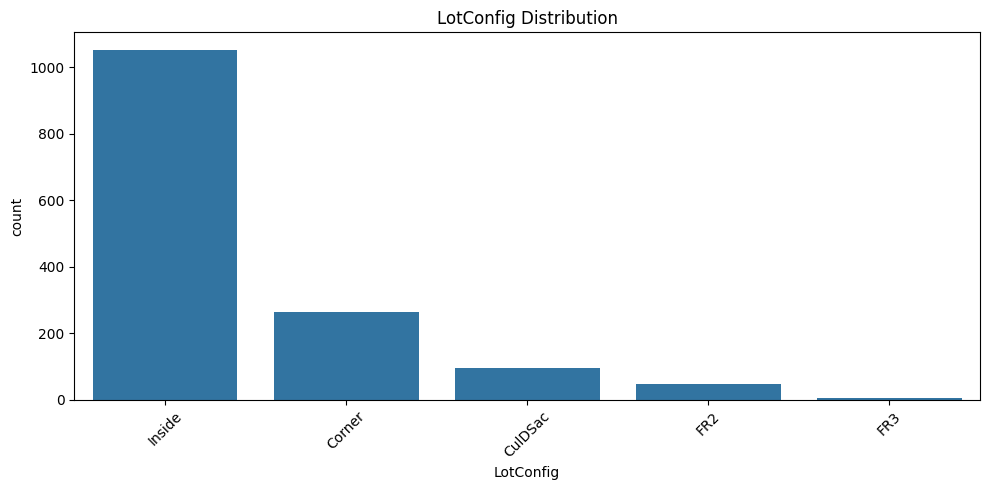

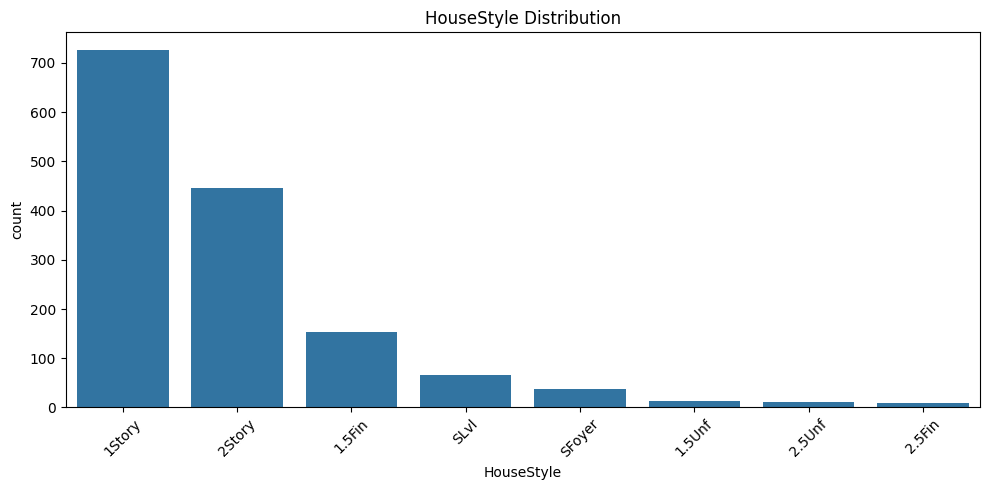

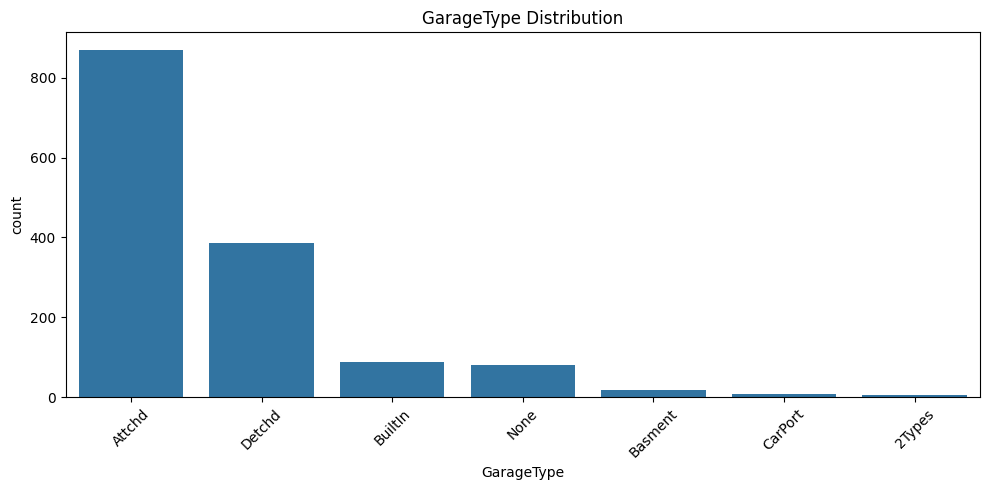

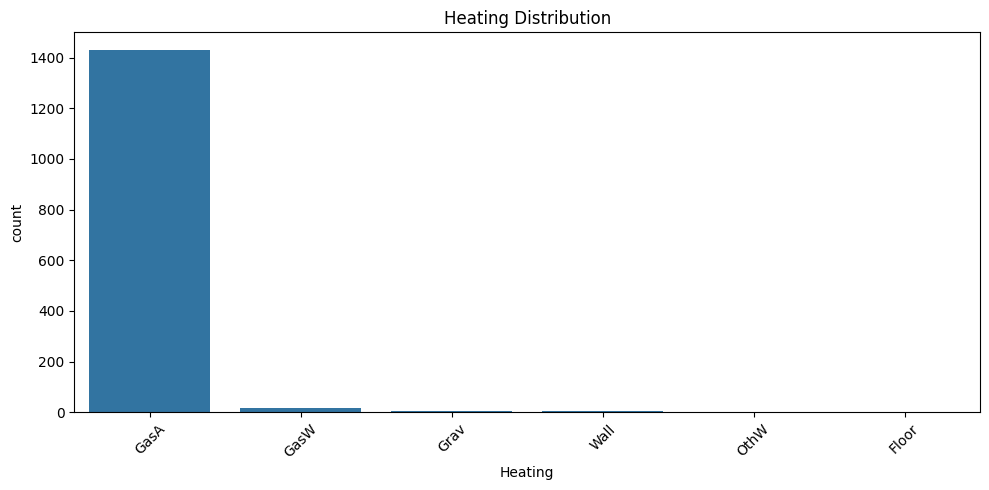

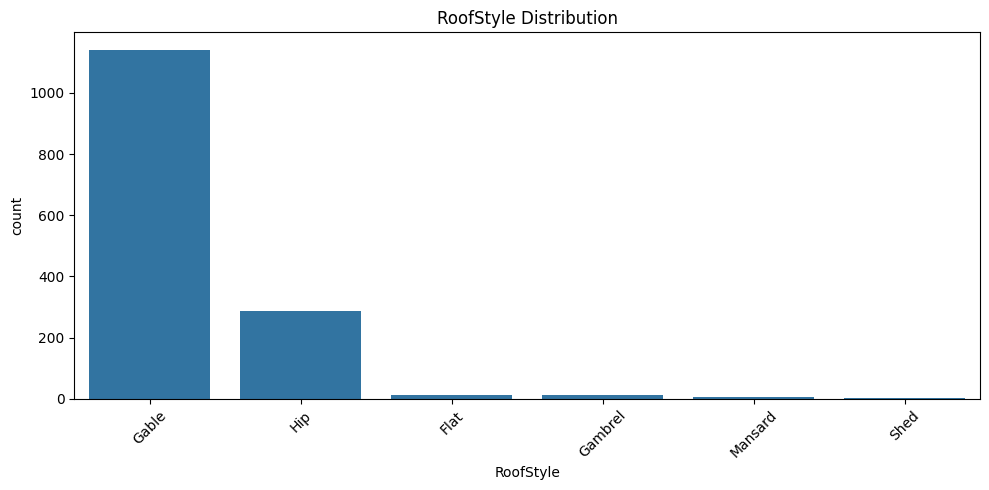

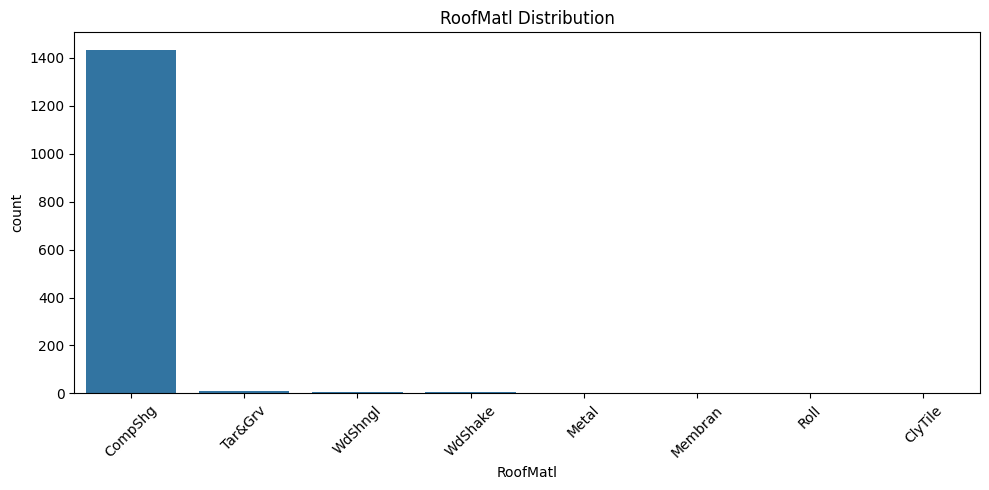

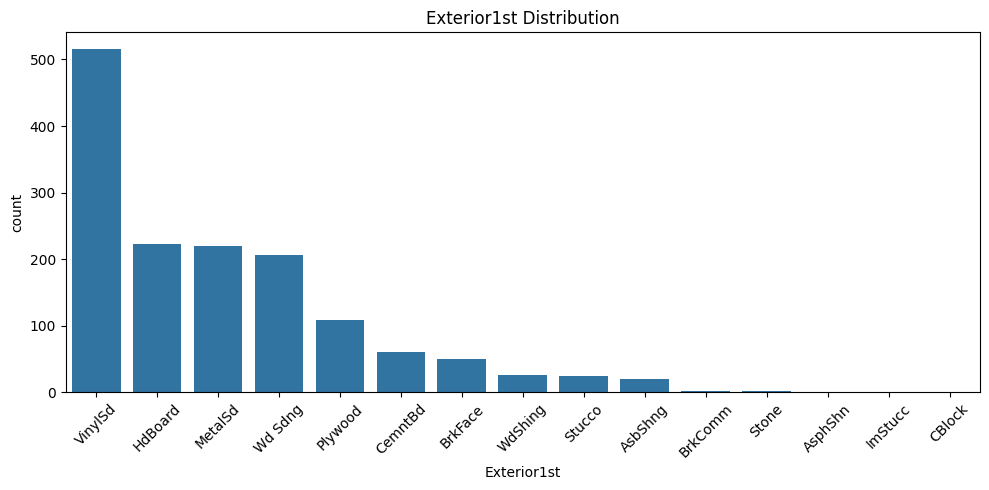

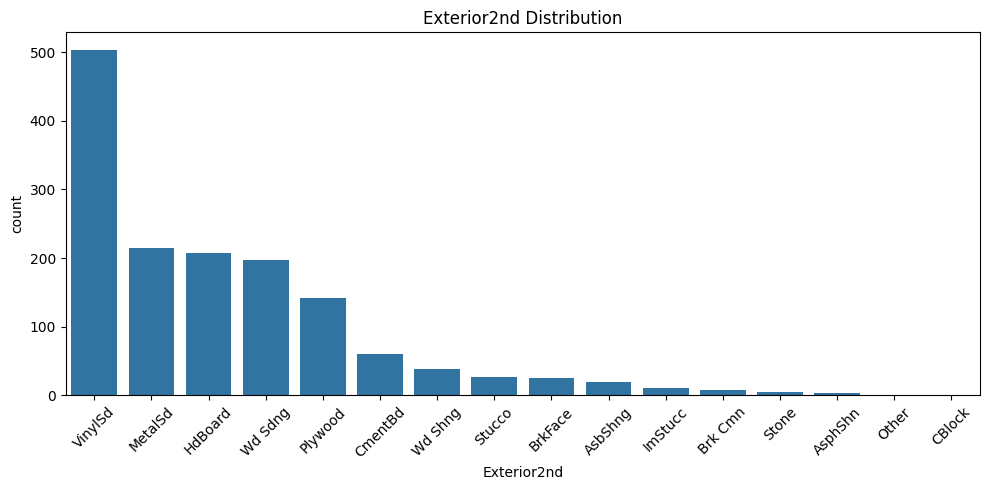

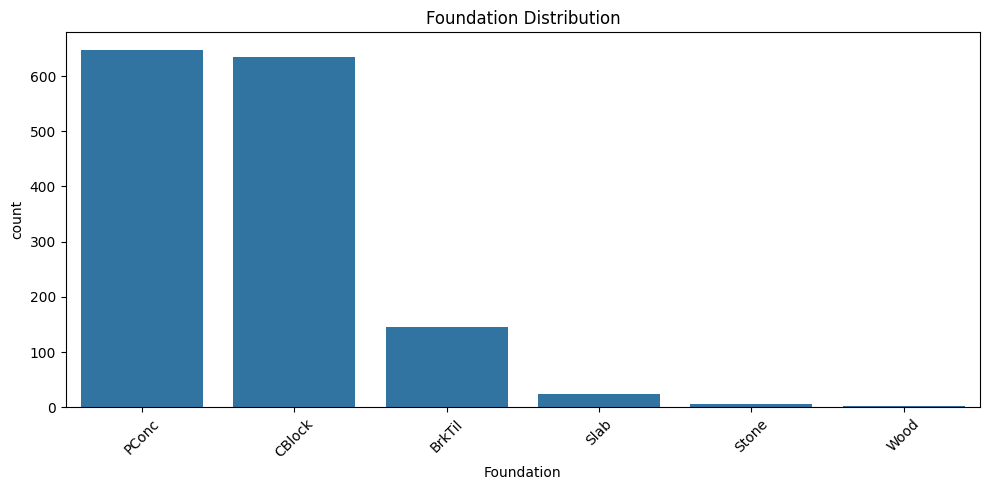

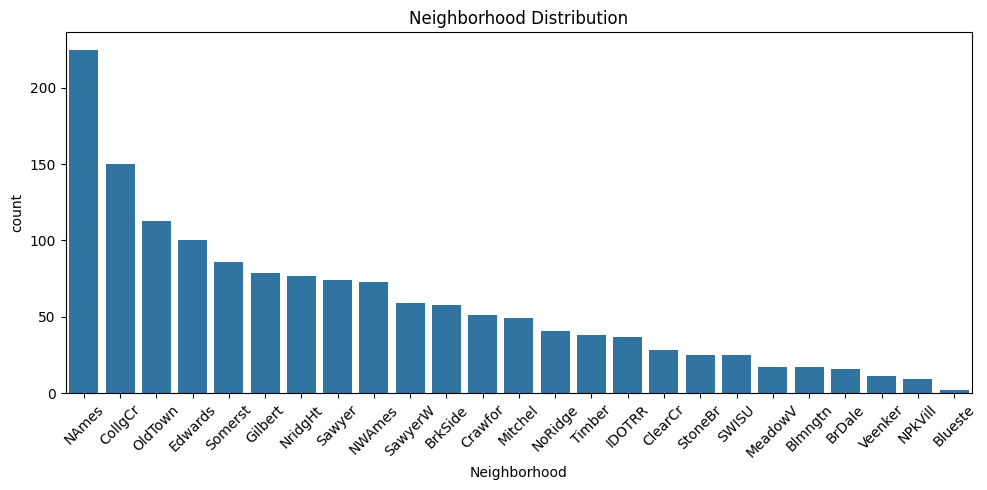

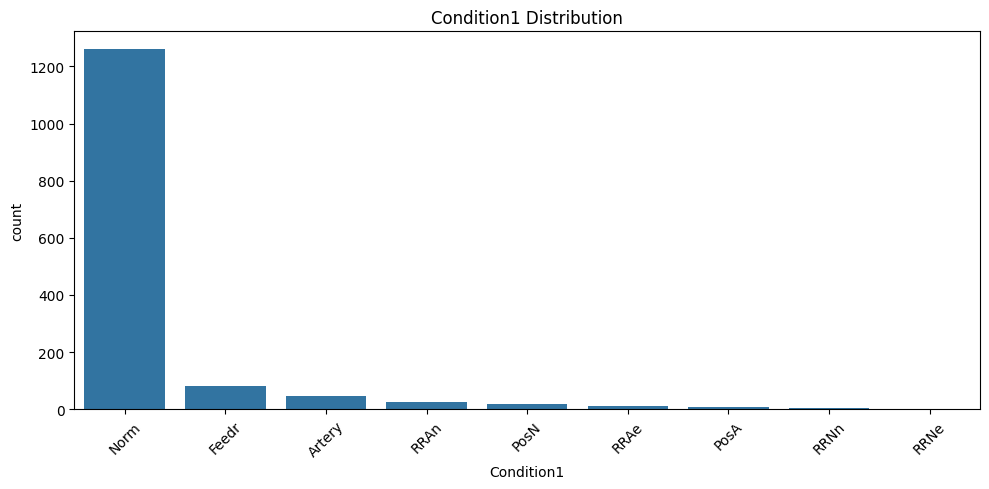

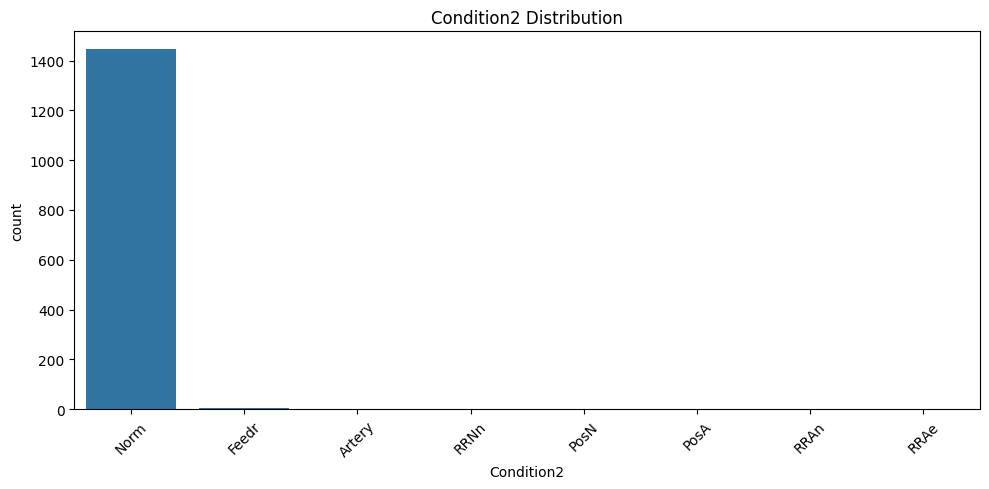

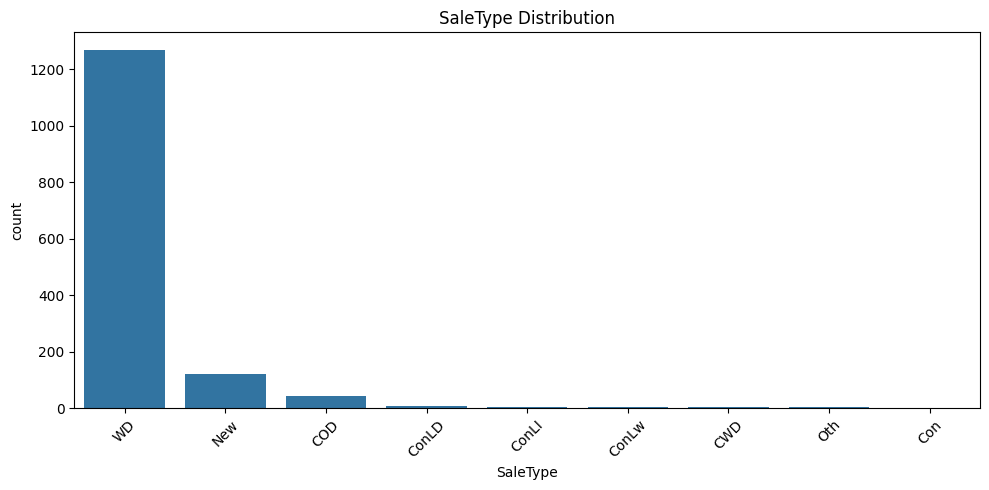

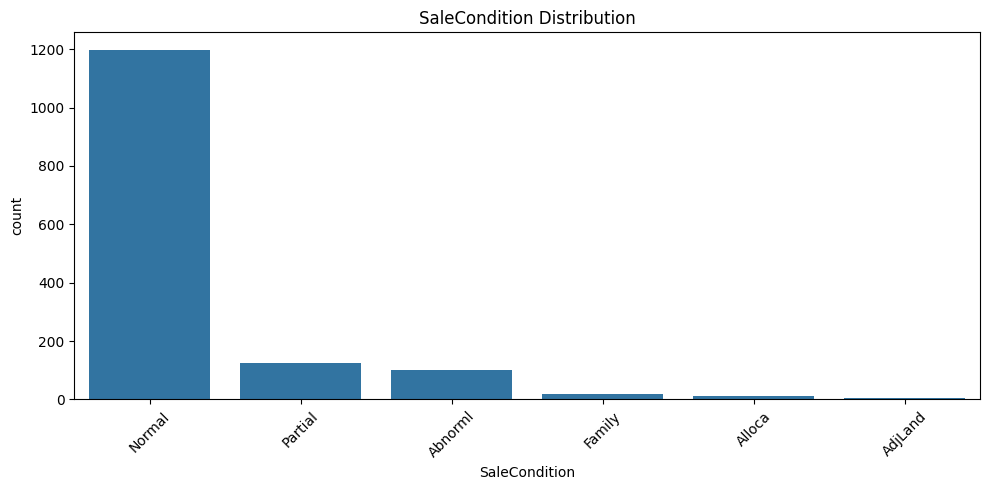

In [72]:
for col in categorical_to_plot:
    plt.figure(figsize=(10, 5))

    plot_data = df.copy()
    plot_data[col] = plot_data[col].fillna('None')

    order = plot_data[col].value_counts().index

    sns.countplot(
        data=plot_data,
        x=col,
        order=order
    )

    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

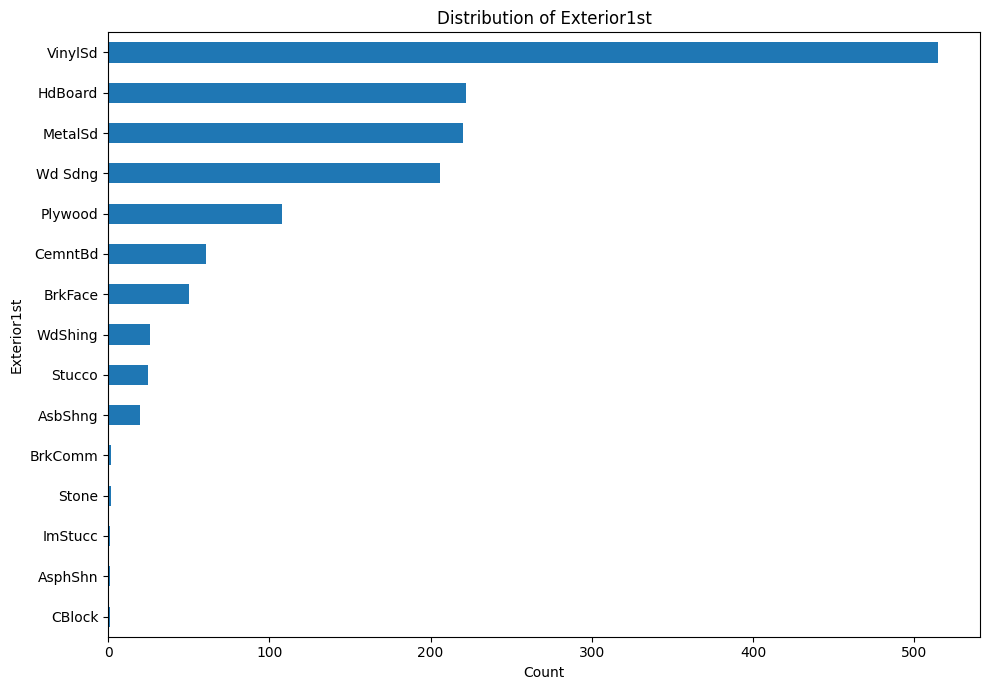

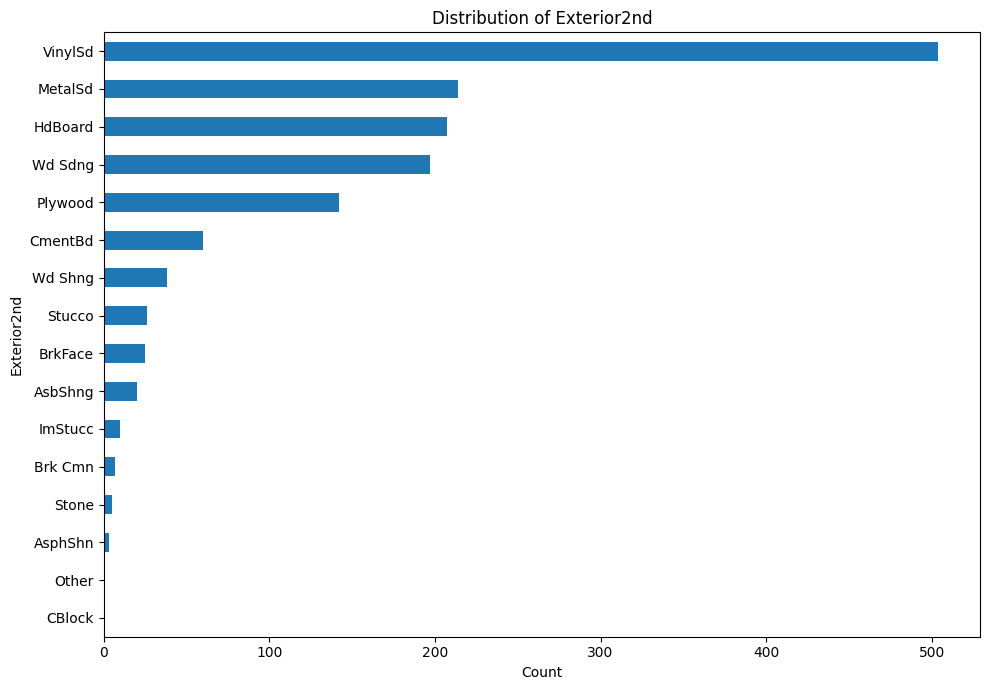

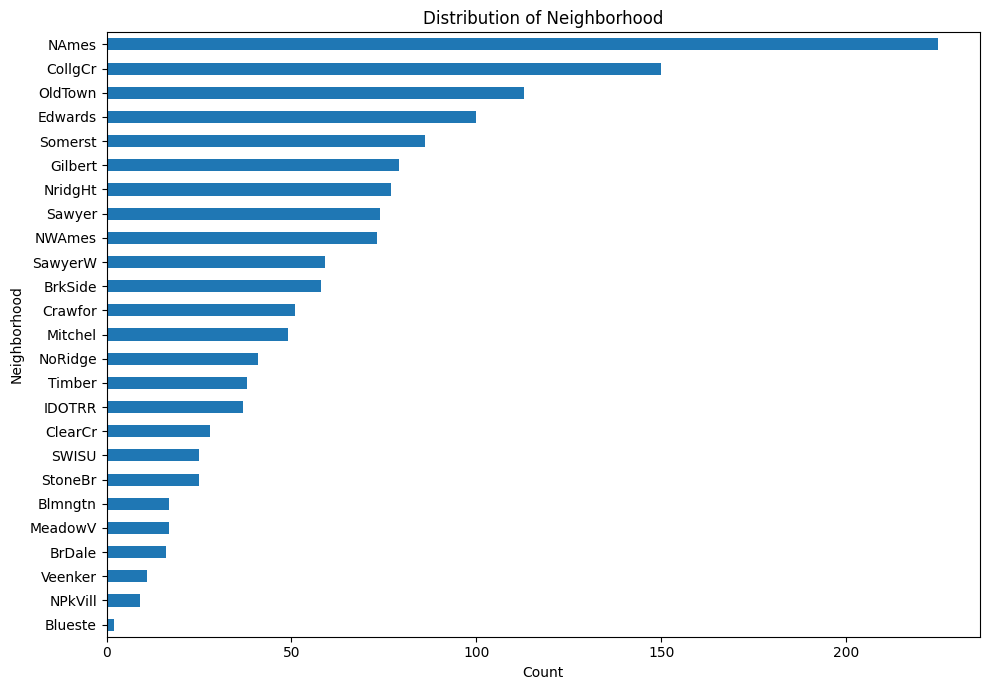

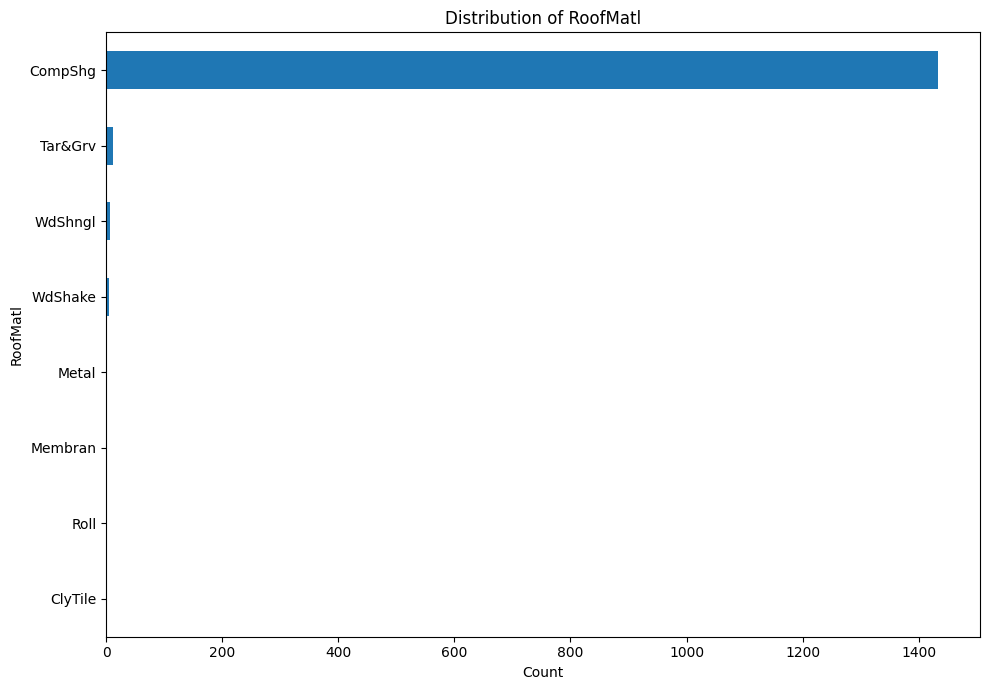

In [73]:
#Plotting horizonal bar charts for categorical features with many categories

many_category_features = [
    'Exterior1st',
    'Exterior2nd',
    'Neighborhood',
    'RoofMatl'
]

for col in many_category_features:
    plt.figure(figsize=(10, 7))

    df[col].value_counts(dropna=False).sort_values().plot(
        kind='barh'
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

| Feature | No. of Categories | Observation |
|---|---:|---|
| `LotShape` | 4 | `Reg` is the dominant category, while `IR3` is very rare. |
| `LandContour` | 4 | `Lvl` is highly dominant, while the other categories are less common. |
| `LandSlope` | 3 | `Gtl` is highly dominant, with `Mod` and `Sev` being rare. |
| `LotConfig` | 5 | `Inside` is the dominant category, while `FR3` is very rare. |
| `BldgType` | 5 | `1Fam` is highly dominant, while the other building types are less common. |
| `HouseStyle` | 8 | `1Story` and `2Story` are the most common styles, while `2.5Fin` is very rare. |
| `BsmtQual` | 4 | `TA` and `Gd` are the most common categories. Missing values are also present. |
| `BsmtCond` | 4 | `TA` is highly dominant, while `Po` is very rare. Missing values are present. |
| `BsmtExposure` | 4 | `No` is the dominant category, while the other categories are less common. Missing values are present. |
| `BsmtFinType1` | 6 | `Unf` and `GLQ` are the most common categories, while `LwQ` is less common. Missing values are present. |
| `BsmtFinType2` | 6 | `Unf` is highly dominant, while `GLQ` and `ALQ` are rare. Missing values are present. |
| `GarageType` | 6 | `Attchd` is the dominant category, followed by `Detchd`. Some categories are very rare and missing values are present. |
| `GarageFinish` | 3 | `Unf` is the most common category, followed by `RFn` and `Fin`. Missing values are present. |
| `GarageQual` | 5 | `TA` is highly dominant, while `Ex` and `Po` are very rare. Missing values are present. |
| `GarageCond` | 5 | `TA` is highly dominant, while `Ex` and `Gd` are rare. Missing values are present. |
| `Heating` | 6 | `GasA` is highly dominant, while the other heating types are very rare. |
| `HeatingQC` | 5 | `Ex` is the most common category, followed by `TA` and `Gd`. `Po` is very rare. |
| `CentralAir` | 2 | `Y` is highly dominant, showing that most properties have central air conditioning. |
| `Electrical` | 5 | `SBrkr` is highly dominant, while `Mix` is very rare. One missing value is present. |
| `Utilities` | 2 | `AllPub` is almost completely dominant, with only one `NoSeWa` observation. |
| `RoofStyle` | 6 | `Gable` is the dominant category, followed by `Hip`. The remaining styles are rare. |
| `RoofMatl` | 8 | `CompShg` is highly dominant, while most other roof materials are very rare. |
| `Exterior1st` | 15 | `VinylSd` is the most common category, while several categories occur only a few times. |
| `Exterior2nd` | 16 | `VinylSd` is the most common category, while several categories are rare. |
| `MasVnrType` | 3 | `BrkFace` is the most common non-missing category. A large number of values are missing. |
| `ExterQual` | 4 | `TA` is the most common category, followed by `Gd`. `Fa` is rare. |
| `ExterCond` | 5 | `TA` is highly dominant, while `Ex` and `Po` are very rare. |
| `Foundation` | 6 | `PConc` and `CBlock` are the most common categories, while `Wood` is very rare. |
| `PoolQC` | 3 | Most values are missing, indicating that most properties do not have a pool. |
| `Fence` | 4 | Most values are missing, indicating that most properties do not have a fence. |
| `MiscFeature` | 4 | Most values are missing, while `Shed` is the most common non-missing category. |
| `MSZoning` | 5 | `RL` is highly dominant, followed by `RM`. The other zoning categories are less common. |
| `Street` | 2 | `Pave` is highly dominant, while `Grvl` is very rare. |
| `Alley` | 2 | Most values are missing, while `Grvl` and `Pave` are less common. |
| `Neighborhood` | 25 | The feature has the highest category diversity. `NAmes` is the most common, while `Blueste` is very rare. |
| `Condition1` | 9 | `Norm` is highly dominant, while several other categories are rare. |
| `Condition2` | 8 | `Norm` is extremely dominant, while the other categories are very rare. |
| `SaleType` | 9 | `WD` is highly dominant, while several other sale types are rare. |
| `SaleCondition` | 6 | `Normal` is the dominant category, while `AdjLand` is very rare. |